In [1]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import re
import json
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy

In [2]:
# отключаем экспоненциальное отображение чисел в pandas и numpy и делаем удобное форматирование
def smart_float(x):
    if pd.isnull(x):
        return ""
    elif float(x).is_integer():
        return '{:.0f}'.format(x) # отображаем целые числа без нулевой десятичной части
    else:
        return '{:.6f}'.format(x).rstrip('0').rstrip('.') # отображаем числа с плавающей запятой без лишних нулей

pd.set_option('display.float_format', smart_float)
np.set_printoptions(suppress=True)
# Снимаем ограничение на число отображаемых столбцов в pandas
pd.set_option('display.max_columns', None)      # показывать все столбцы
pd.set_option('display.width', None)            # не ограничивать ширину вывода
pd.set_option('display.max_colwidth', None)     # не ограничивать ширину столбца

## 3.1 Считываем данные для работы

In [3]:
data = pd.read_parquet('fraud_after_EDA.parquet')

with open('fraud_after_EDA_schema.json', 'r', encoding='utf-8') as f:
    schema = json.load(f)

# сначала datetime
for col in schema['datetime_cols']:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

# потом category
for col in schema['category_cols']:
    if col in data.columns:
        data[col] = data[col].astype('category')

# потом остальные типы
for col, dtype_str in schema['dtypes'].items():
    if col not in data.columns:
        continue
    
    if col in schema['datetime_cols'] or col in schema['category_cols']:
        continue
    
    try:
        if dtype_str == 'object':
            data[col] = data[col].astype('string')
        else:
            data[col] = data[col].astype(dtype_str)
    except Exception as e:
        print(f'Не удалось привести {col} к {dtype_str}: {e}')

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 42 columns):
 #   Column              Dtype         
---  ------              -----         
 0   User                int16         
 1   Card                int8          
 2   Timestamp           datetime64[ns]
 3   Amount              float32       
 4   Use_Chip            int8          
 5   Is_Online           int8          
 6   Merchant_ID         int32         
 7   Merchant_City       category      
 8   Merchant_State      category      
 9   Merchant_Zip        category      
 10  Merchant_USA        int8          
 11  MCC                 int16         
 12  Has_Error           int8          
 13  Errors              category      
 14  Fraud               int8          
 15  Current_Age         int8          
 16  Retirement_Age      int8          
 17  Birth_Year          int16         
 18  Birth_Month         int8          
 19  Gender              int8          
 20  

In [4]:
data.head()

,User,Card,Timestamp,Amount,Use_Chip,Is_Online,Merchant_ID,Merchant_City,Merchant_State,Merchant_Zip,Merchant_USA,MCC,Has_Error,Errors,Fraud,Current_Age,Retirement_Age,Birth_Year,Birth_Month,Gender,Is_Apartment,User_City,User_State,User_Zip,Yearly_Income,Total_Debt,FICO,Num_Credit_Cards,Card_Brand,Card_Type,Expires,Has_Chip,Cards_Issued,Credit_Limit,Account_Open_Date,txn_hour,txn_dayofweek,txn_month,txn_day,is_weekend,account_age_months,card_expiry_months
0,0,0,2002-09-01 06:21:00,134.089996,0,0,69374,La Verne,CA,91750.0,1,5300,0,No_Error,0,53,66,1966,11,0,0,La Verne,CA,91750,59696,127613,787,5,Visa,Debit,2022-12-31,1,2,24295,2002-09-01,6,6,9,1,1,0,247
1,0,0,2002-09-01 06:42:00,38.48,0,0,46284,Monterey Park,CA,91754.0,1,5411,0,No_Error,0,53,66,1966,11,0,0,La Verne,CA,91750,59696,127613,787,5,Visa,Debit,2022-12-31,1,2,24295,2002-09-01,6,6,9,1,1,0,247
2,0,0,2002-09-02 06:22:00,120.339996,0,0,46284,Monterey Park,CA,91754.0,1,5411,0,No_Error,0,53,66,1966,11,0,0,La Verne,CA,91750,59696,127613,787,5,Visa,Debit,2022-12-31,1,2,24295,2002-09-01,6,0,9,2,0,0,247
3,0,0,2002-09-02 17:45:00,128.949997,0,0,68751,Monterey Park,CA,91754.0,1,5651,0,No_Error,0,53,66,1966,11,0,0,La Verne,CA,91750,59696,127613,787,5,Visa,Debit,2022-12-31,1,2,24295,2002-09-01,17,0,9,2,0,0,247
4,0,0,2002-09-03 06:23:00,104.709999,0,0,81833,La Verne,CA,91750.0,1,5912,0,No_Error,0,53,66,1966,11,0,0,La Verne,CA,91750,59696,127613,787,5,Visa,Debit,2022-12-31,1,2,24295,2002-09-01,6,1,9,3,0,0,247


Для упрощения работы признаки с заглавной буквы - признаки, которые были в датасете изначально. Признаки с маленькой буквы - признаки, созданные вручную. При кодировании правило соблюдаться не будет.

## 3.2 Работа с признаками, которые можно вычислить в пределах строки

Сначала мы займемся производными признаками - теми, которые вычисляются в пределах одной строки. Такие признаки не подвержены риску утечки данных и их можно выполнить до разбиения датасета, что упрощает нам работу.

In [5]:
# Перепроверим одинаковость значений в колонках
data.loc[data['Is_Online'] == 1, ['Merchant_State','Merchant_City','Merchant_Zip']], data.loc[data['Is_Online'] == 1,
                                ['Merchant_State','Merchant_City','Merchant_Zip']].nunique()

(         Merchant_State Merchant_City Merchant_Zip
 11               ONLINE        ONLINE      Unknown
 24               ONLINE        ONLINE      Unknown
 83               ONLINE        ONLINE      Unknown
 97               ONLINE        ONLINE      Unknown
 104              ONLINE        ONLINE      Unknown
 ...                 ...           ...          ...
 23142195         ONLINE        ONLINE      Unknown
 23142197         ONLINE        ONLINE      Unknown
 23142198         ONLINE        ONLINE      Unknown
 23142202         ONLINE        ONLINE      Unknown
 23142207         ONLINE        ONLINE      Unknown
 
 [2703530 rows x 3 columns],
 Merchant_State    1
 Merchant_City     1
 Merchant_Zip      1
 dtype: int64)

In [6]:
# Поскольку для онлайн-транзакций эти колонки неинформативные, заменим их на NaN
data.loc[data['Is_Online'] == 1, ['Merchant_State', 'Merchant_City']] = np.nan

In [7]:
# Создаём новый признак заграничности транзакции (он-лайн не будут считаться заграничными)
state_is_us = data['Merchant_State'].str.fullmatch(r'[A-Z]{2}').fillna(False)

data['Is_Foreign'] = (~state_is_us).astype('int8')

C:\Users\dmytr\AppData\Local\Temp\ipykernel_36364\2495009370.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  state_is_us = data['Merchant_State'].str.fullmatch(r'[A-Z]{2}').fillna(False)


In [8]:
# Проверяем отсутствие ошибок (что транзакция получила 1 в обоих признаках)
pd.crosstab(data['Is_Foreign'], data['Merchant_USA'])

Merchant_USA,0,1
Is_Foreign,,
0,0,20296091
1,2846126,0


In [9]:
# Удалчем колонку Merchant_USA
data.drop(columns=['Merchant_USA'], inplace=True)

In [10]:
# У нас есть информация о годовом доходе клиента и мы установили, что она достаточно точная. 
# Для выявления типичности транзакции ждля клиента создадим новый показатель - отношение суммы транзакции к среднемесячномудоходу клиента.
data['Amount_to_Income'] = data['Amount'] / (data['Yearly_Income'] / 12).replace(0, np.nan)

In [11]:
# Удаляем годовой доход т.к. он нам больше не нужен + он создат мультирколлинеарность с новым признаком
data.drop(columns=['Yearly_Income'], inplace=True)

In [12]:
# Создаём признак транзакции в том же городе, где живёт клиент. Проверяем и город и штат т.к. много названий городов повторяется. 
data['same_city'] = (
    (data['Merchant_City'].astype('object') == data['User_City'].astype('object')) &
    (data['Merchant_State'].astype('object') == data['User_State'].astype('object'))
).astype('int8')


# создаём признак нахождения в том же штате
data['same_state'] = (
    data['Merchant_State'].astype('object') == data['User_State'].astype('object')
).astype('int8')
# Удаляем признаки города и кода продавца и все географические признаки покупателя, т.к. они имеют высокую кардинальность, а их
# информация уже частично сохранена в новых признаках. Оставим только страну или штат продавца т.к. EDA показала значимость признака и категорий
# там не много.
data.drop(columns=['Merchant_City', 'Merchant_Zip', 'User_City', 'User_State', 'User_Zip'], inplace=True)

In [13]:
# Сейчас причины ошибок представлены в виде строк, при этом если причина ошибки не одна - они объединены в одну строку через запятую. Поскольку причин ошибок
# мало есть смысл создать отдельные признаки для каждой причины ошибки.
error_dummies = data['Errors'].str.get_dummies(sep=',')

error_dummies.columns = [
    'Error_' + col.strip().replace(' ', '_')
    for col in error_dummies.columns
]

error_dummies.drop(columns=['Error_No_Error'], errors='ignore', inplace=True) # колнка "нет ошибки" не несёт полезной информации, удалим её
error_dummies = error_dummies.astype('int8')
# Добавляем новые признаки в основной датафрейм
data = pd.concat([data, error_dummies], axis=1) 

In [14]:
# Проверим, что мы не создали слишком много новых признаков и что они не слишком разреженные
error_dummies.sum().sort_values(ascending=False)

Error_Insufficient_Balance    231760
Error_Bad_PIN                  56951
Error_Technical_Glitch         46635
Error_Bad_Card_Number          13575
Error_Bad_CVV                  10935
Error_Bad_Expiration           10923
Error_Bad_Zipcode               1812
dtype: int64

In [15]:
# Удаляем исходный признак с ошибками, он нам больше не нужен
data.drop(columns=['Errors'], inplace=True)
# Удаляем временную таблицу
del error_dummies
gc.collect()

36

In [16]:
# Обновляем данные о текущем возврасте клиента (делаем его актуальным именно на день транзакции)
data['user_age'] = (
    data['Timestamp'].dt.year - data['Birth_Year'] -
    (data['Timestamp'].dt.month < data['Birth_Month']) # если транзакция случилась до месяца рождения то отнимаем 1 год
).astype('int16')

In [17]:
# Удаляем не нужные теперь колонки с годом и месяцем рождения и исходную колонку с возрастом, т.к. она уже не актуальна
data.drop(columns=['Birth_Year', 'Birth_Month', 'Current_Age'], inplace=True)


In [18]:
# Создаём колонку "Осталось до выхода на пенсию" - вроде бы по EDA признак был слабый, но пока оставим
data['years_to_retirement'] = (data['Retirement_Age'] - data['user_age']).clip(lower=0).astype('int8') # если клиент уже на пенсии, то ставим 0
# Удаляем старую колонку
data.drop(columns=['Retirement_Age'], inplace=True)
# В конце перепроверим мультиколлинеарность и, возможно, заменим признак на is_retired

In [19]:
# Удаляем признаки, из которых мы получили показательные во время EDA
data.drop(columns=['Account_Open_Date', 'Expires'], inplace=True)

In [20]:
# добавим ещё два временных показателя - ночь и рабочее время
data['is_night'] = ((data['Timestamp'].dt.hour >= 0) & (data['Timestamp'].dt.hour < 6)).astype('int8')
data['is_business_hours'] = ((data['Timestamp'].dt.hour >= 9) & (data['Timestamp'].dt.hour < 18) & (data['is_weekend'] == 0)).astype('int8')

In [21]:
# Полезный дополнительный признак - логарифм суммы транзакции. Он может помочь модели лучше работать с широким диапазоном сумм и выявлять аномалии.
data['amount_log'] = np.log1p(data['Amount']).astype('float32') # log1p используется для корректной обработки нулевых значений

In [22]:
# Создадим признак "целлая сумма кратная десятке" (мошенники часто пытаются снять ровные суммы)
amount_cents = (data['Amount'] * 100).round().astype('int32')
data['amount_round_10'] = (amount_cents % 1000 == 0).astype('int8')
del amount_cents

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 45 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   User                        int16         
 1   Card                        int8          
 2   Timestamp                   datetime64[ns]
 3   Amount                      float32       
 4   Use_Chip                    int8          
 5   Is_Online                   int8          
 6   Merchant_ID                 int32         
 7   Merchant_State              category      
 8   MCC                         int16         
 9   Has_Error                   int8          
 10  Fraud                       int8          
 11  Gender                      int8          
 12  Is_Apartment                int8          
 13  Total_Debt                  float32       
 14  FICO                        int16         
 15  Num_Credit_Cards            int8          
 16  Card_Brand      

## 3.3 Сортировка по времени и создание временных признаков

In [24]:
# Проверим сколько дублирующихся временных признаков (т.к. в исходном датасете не было секунд) 
(data['Timestamp'].value_counts() > 1).sum()

np.int64(5243274)

In [25]:
# Проведём сортировку по времени транзакции. В случае равной транзакции условно отсортируем транзакции по идентификатору пользователя, 
# а при совпадении - идентификатору карты.
data.sort_values(['Timestamp','User','Card'], kind='mergesort', inplace=True)
data.reset_index(drop=True, inplace=True)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 45 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   User                        int16         
 1   Card                        int8          
 2   Timestamp                   datetime64[ns]
 3   Amount                      float32       
 4   Use_Chip                    int8          
 5   Is_Online                   int8          
 6   Merchant_ID                 int32         
 7   Merchant_State              category      
 8   MCC                         int16         
 9   Has_Error                   int8          
 10  Fraud                       int8          
 11  Gender                      int8          
 12  Is_Apartment                int8          
 13  Total_Debt                  float32       
 14  FICO                        int16         
 15  Num_Credit_Cards            int8          
 16  Card_Brand      

In [27]:
data.head()

,User,Card,Timestamp,Amount,Use_Chip,Is_Online,Merchant_ID,Merchant_State,MCC,Has_Error,Fraud,Gender,Is_Apartment,Total_Debt,FICO,Num_Credit_Cards,Card_Brand,Card_Type,Has_Chip,Cards_Issued,Credit_Limit,txn_hour,txn_dayofweek,txn_month,txn_day,is_weekend,account_age_months,card_expiry_months,Is_Foreign,Amount_to_Income,same_city,same_state,Error_Bad_CVV,Error_Bad_Card_Number,Error_Bad_Expiration,Error_Bad_PIN,Error_Bad_Zipcode,Error_Insufficient_Balance,Error_Technical_Glitch,user_age,years_to_retirement,is_night,is_business_hours,amount_log,amount_round_10
0,791,1,1991-01-02 07:10:00,68,0,0,61195,VA,5541,0,0,1,1,44317,727,4,Amex,Credit,1,2,33900,7,2,1,2,0,0,405,0,0.011254,1,1,0,0,0,0,0,0,0,29,38,0,0,4.234107,0
1,791,1,1991-01-02 07:21:00,113.620003,0,0,61195,VA,5541,0,0,1,1,44317,727,4,Amex,Credit,1,2,33900,7,2,1,2,0,0,405,0,0.018803,1,1,0,0,0,0,0,0,0,29,38,0,0,4.741622,0
2,791,1,1991-01-02 17:30:00,114.730003,0,0,10792,VA,5411,0,0,1,1,44317,727,4,Amex,Credit,1,2,33900,17,2,1,2,0,0,405,0,0.018987,1,1,0,0,0,0,0,0,0,29,38,0,1,4.75126,0
3,791,1,1991-01-03 09:03:00,251.710007,0,0,30286,VA,4814,0,0,1,1,44317,727,4,Amex,Credit,1,2,33900,9,3,1,3,0,0,405,0,0.041657,1,1,0,0,0,0,0,0,0,29,38,0,1,5.532243,0
4,791,1,1991-01-03 11:14:00,16.280001,0,0,10792,VA,5411,0,0,1,1,44317,727,4,Amex,Credit,1,2,33900,11,3,1,3,0,0,405,0,0.002694,1,1,0,0,0,0,0,0,0,29,38,0,1,2.84955,0


In [28]:
# Начнём с признака "разрывы между транзакциями" т.к. при мошенничестве часто встречаются повторяющиеся транзакции
data['time_since_prev_txn_card_min'] = (
    data.groupby(['User','Card'])['Timestamp']
        .diff()
        .dt.total_seconds()
        .div(60)
        .astype('float32')
)

# для первой транзакции ставим -1
data['time_since_prev_txn_card_min'] = data['time_since_prev_txn_card_min'].fillna(-1)

In [29]:
# Аналогично для пользователя, т.к. мошенник может использовать разные карты, но при этом совершать транзакции с короткими разрывами
data['time_since_prev_txn_user_min'] = (
    data.groupby('User')['Timestamp']
        .diff()
        .dt.total_seconds()
        .div(60)
        .astype('float32')
)

data['time_since_prev_txn_user_min'] = data['time_since_prev_txn_user_min'].fillna(-1)

In [30]:
# Смотрим есть ли в признаках смысл - в скольких случаях разрывы между транзакциями по карте и по пользователю не совпадают. 
# Если таких случаев много, то, возможно, стоит оставить только один из признаков, чтобы не создавать мультиколлинеарность.
(data['time_since_prev_txn_card_min'] != 
 data['time_since_prev_txn_user_min']).sum()

np.int64(8653497)

In [31]:
# Сколько случаев транзакции в туже минуту
(data['time_since_prev_txn_card_min'] == 0).sum()

np.int64(61320)

Делаем вывод - в признаках есть смысл

In [32]:
# Дополнительный признак - категории повторности транзакций
gap = data['time_since_prev_txn_card_min'].clip(lower=0) # заменяем -1 на 0 для удобства категоризации
data['txn_gap_bin'] = np.select(
    [
        data['time_since_prev_txn_card_min'] == -1,
        gap == 0,
        gap <= 1,
        gap <= 5,
        gap <= 30,
        gap <= 120,
        gap <= 1440
    ],
    [
        0,  # первая транзакция
        1,  # транзакция в ту же минуту
        2,  # <=1 min
        3,  # <=5 min
        4,  # <=30 min
        5,  # <=2h
        6   # <=1 day
    ],
    default=7  # >1 day
).astype('int8')

In [33]:
data['txn_gap_bin'].value_counts().sort_index()

txn_gap_bin
0        6139
1       61320
2      123336
3      462120
4     1989505
5     2795235
6    12519520
7     5185042
Name: count, dtype: int64

In [34]:
# Проверяем впервые ли пользователь платит именно этому продавцу.
data['first_user_payment_to_this_merchant'] = (
    data.groupby(['User', 'Merchant_ID'])
    .cumcount()
    .eq(0)
    .astype('int8')
)

In [35]:
# Хороший показатель мошенничества - если по карте подряд идёт много транзакций. Создаём показатель "число транзакций по карте за последние 5 минут"
data = data.reset_index(drop=True)

data['txn_count_5m_card'] = (
    data
    .set_index('Timestamp')
    .groupby(['User', 'Card'])['Card']
    .rolling('5min')
    .count()
    .reset_index(level=[0,1], drop=True)
    .astype('int8')
    .values  # чтобы избежать проблем с индексами при присваивании
)
# Проверяем распределение признака
data['txn_count_5m_card'].value_counts().sort_index()

txn_count_5m_card
1    22606772
2      524123
3       10699
4         616
5           7
Name: count, dtype: int64

In [36]:
# Создадим аналогичный признак для 1 часа
data['txn_count_1h_card'] = (
    data
    .set_index('Timestamp')
    .groupby(['User', 'Card'])['Card']
    .rolling('1h')
    .count()
    .reset_index(level=[0,1], drop=True)
    .astype('int8')
    .values  # чтобы избежать проблем с индексами при присваивании
)
# Проверяем распределение признака
data['txn_count_1h_card'].value_counts().sort_index()

txn_count_1h_card
1     19254218
2      3335666
3       437992
4        96373
5        14403
6         3044
7          436
8           73
9           10
10           2
Name: count, dtype: int64

In [37]:
# Аналогичный показатель для разных карт одного и того же пользователя

data['txn_count_5m_user'] = (
    data
    .set_index('Timestamp')
    .groupby('User')['User']
    .rolling('5min')
    .count()
    .reset_index(level=0, drop=True)
    .astype('int8')
    .values
)
data['txn_count_1h_user'] = (
    data
    .set_index('Timestamp')
    .groupby('User')['User']
    .rolling('1h')
    .count()
    .reset_index(level=0, drop=True)
    .astype('int8')
    .values
)
# Проверяем распределение
print(data['txn_count_5m_user'].value_counts().sort_index())
print()
print(data['txn_count_1h_user'].value_counts().sort_index())

txn_count_5m_user
1    22461389
2      665530
3       14593
4         694
5          11
Name: count, dtype: int64

txn_count_1h_user
1     17479463
2      4613085
3       835384
4       177373
5        29950
6         5886
7          908
8          145
9           19
10           3
11           1
Name: count, dtype: int64


In [38]:
# Ещё один географический признак - смена страны или штата за последние сутки
prev_state = data.groupby(['User','Card'])['Merchant_State'].shift()

data['state_changed_1d'] = (
    (prev_state != data['Merchant_State']) &
    (data['time_since_prev_txn_card_min'] <= 1440) &
    (data['time_since_prev_txn_card_min'] >= 0)
).astype('int8')
# Проверяем распределение признака
data['state_changed_1d'].value_counts()

state_changed_1d
0    18687672
1     4454545
Name: count, dtype: int64

In [39]:
# Признак - успех после отказа. Если после отказа по карте следующая транзакция по той же карте идёт с тем же мерчантом,
# признак принимает значение 1. Ловит попытки подобрать сумму, CVV код или пин-код в банкомате.
# Столбцы с кодами ошибок, которые мы создали ранее
error_cols = [
    'Error_Bad_CVV',
    'Error_Bad_Card_Number',
    'Error_Bad_Expiration',
    'Error_Bad_PIN',
    'Error_Bad_Zipcode',
    'Error_Insufficient_Balance',
    'Error_Technical_Glitch'
]
# Колонки, разница в которых не учитывается при проверке идентичности
exclude_cols = error_cols + ['Timestamp', 'Amount', 'Has_Error', 'Fraud']
# Что сравниваем
key_cols = [c for c in data.columns if c not in exclude_cols]

# Есть ли ошибка в транзакции
any_error = data[error_cols].max(axis=1).astype('int8')

# Сигнатура "все одинаково, кроме указанного в исключении" - делаем через хеширование
signature = pd.util.hash_pandas_object(
    data[key_cols],
    index=False
)

# Предыдущщая похожая транзакция была с ошибкой
data['retry_after_error'] = (
    any_error
    .groupby(signature, sort=False)
    .shift()
    .fillna(0)
    .astype('int8')
)
# Проверяем распределение признака
data['retry_after_error'].value_counts()

retry_after_error
0    23141773
1         444
Name: count, dtype: int64

In [40]:
# Смотрим есть ли в смысл в новом признаке - насколько он коррелирует с мошенничеством
pd.crosstab(data['retry_after_error'], data['Fraud'])

Fraud,0,1
retry_after_error,,
0,23113141,28632
1,444,0


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23142217 entries, 0 to 23142216
Data columns (total 55 columns):
 #   Column                               Dtype         
---  ------                               -----         
 0   User                                 int16         
 1   Card                                 int8          
 2   Timestamp                            datetime64[ns]
 3   Amount                               float32       
 4   Use_Chip                             int8          
 5   Is_Online                            int8          
 6   Merchant_ID                          int32         
 7   Merchant_State                       category      
 8   MCC                                  int16         
 9   Has_Error                            int8          
 10  Fraud                                int8          
 11  Gender                               int8          
 12  Is_Apartment                         int8          
 13  Total_Debt               

In [42]:
# Новый признак бесполезен - он наоборот может запутать модель, показав, что повторная транзакция после ошибки менее подозрительна.
# Удалим его, а также все созданные переменные
data.drop(columns=['retry_after_error'], inplace=True)
del error_cols, exclude_cols, key_cols, any_error, signature
gc.collect()

0

In [43]:
# Создаём другой признак - счётчик числа ошибок перед текущей транзакцией за последний час по той же карте
# Колонки ошибок (да, я знаю, что мы только что его удалили - я предпочитаю делать фрагменты кода самодостаточными, чтобы не зависить от порядка исполнения или удаления предыдущих ячеек)
error_cols = [
    'Error_Bad_CVV',
    'Error_Bad_Card_Number',
    'Error_Bad_Expiration',
    'Error_Bad_PIN',
    'Error_Bad_Zipcode',
    'Error_Insufficient_Balance',
    'Error_Technical_Glitch'
]

# По каким признакам считаем "попытки" (карта + мерчант)
group_cols = ['User', 'Card', 'Merchant_ID']   # идентификаторы

# Создаём временный бинарный флаг "в этой транзакции была ошибка"
data['_any_error'] = data[error_cols].any(axis=1).astype('int8')

# Чтобы учитывать "в ту же минуту": делаем уникальное время внутри одинакового Timestamp
# (ранние строки в минуте получают меньший _ts_adj, поздние — больший) - в реальном датасете будут секунды, так что коллизий будет меньше, но на всякий случай сделаем
dup_rank = data.groupby(group_cols + ['Timestamp'], sort=False).cumcount()
data['_ts_adj'] = data['Timestamp'] + pd.to_timedelta(dup_rank, unit='ns')
# Сбросим индекс для уникальности
data = data.reset_index(drop=True)
# Счётчик ошибок за 1 час ДО текущей транзакции (closed='left' исключает текущую)
data['errors_prev_1h'] = (
    data.groupby(group_cols, sort=False)
        .rolling('60min', on='_ts_adj', closed='left')['_any_error']
        .sum()
        .reset_index(level=group_cols, drop=True)
        .fillna(0)                
        .astype('int16')
        .values
)

# Удаляем временные колонки
data.drop(columns=['_any_error', '_ts_adj'], inplace=True)
# Проверяем распределение признака
data['errors_prev_1h'].value_counts().sort_index()

errors_prev_1h
0    22999227
1      132089
2       10618
3         278
4           4
5           1
Name: count, dtype: int64

In [44]:
# Проверяем есть ли смысл в новом признаке - насколько он коррелирует с мошенничеством
pd.crosstab(data['errors_prev_1h'], data['Fraud'])

Fraud,0,1
errors_prev_1h,,
0,22970796,28431
1,131905,184
2,10601,17
3,278,0
4,4,0
5,1,0


In [45]:
# Пока признак оставим
# Удалим временные переменные, которые мы создали для подсчёта признака
del error_cols, group_cols, dup_rank
gc.collect()


0

In [46]:
# Новые признаки - количество транзакций у мерчанта и сумма продаж за последние сутки перед транзакцией. Теория в том, что у крупных мерчантов
# может быть много транзакций, и это может быть нормой, а для мелких мерчантов большое количество транзакций может быть подозрительным. 
# Аналогично с суммой продаж - для крупных мерчантов большие суммы могут быть нормой, а для мелких - подозрительными.
data.reset_index(drop=True, inplace=True)

group_col = 'Merchant_ID' 

# На случай одинаковых Timestamp у одного и того же мерчанта:
# добавляем микросмещение, чтобы транзакции в ту же минуту/секунду тоже учитывались по порядку строк
dup_rank = data.groupby([group_col, 'Timestamp'], sort=False).cumcount()
data['_ts_adj'] = data['Timestamp'] + pd.to_timedelta(dup_rank, unit='ns')

# Служебная колонка для подсчета количества
data['_txn_one'] = 1

# Количество транзакций у мерчанта за последние 24 часа ДО текущей
txn_count = (
    data.groupby(group_col, sort=False)
        .rolling('24h', on='_ts_adj', closed='left')['_txn_one']
        .sum()
        .reset_index(level=0, drop=True)
)

# Сумма покупок у мерчанта за последние 24 часа ДО текущей
txn_sum = (
    data.groupby(group_col, sort=False)
        .rolling('24h', on='_ts_adj', closed='left')['Amount']
        .sum()
        .reset_index(level=0, drop=True)
)

data['merchant_txn_count_24h'] = txn_count.fillna(0).astype('int32').to_numpy()
data['merchant_amount_sum_24h'] = txn_sum.fillna(0).astype('float32').to_numpy()

# Удаляем временные колонки
data.drop(columns=['_ts_adj', '_txn_one'], inplace=True)

# Проверяем распределение новых признаков
print(data['merchant_txn_count_24h'].value_counts().sort_index())
print()
print(data['merchant_amount_sum_24h'].describe())

merchant_txn_count_24h
0      5838477
1      1515801
2       621918
3       424994
4       365587
        ...   
311          4
312          6
313          8
314          6
315          2
Name: count, Length: 316, dtype: int64

count      23142217
mean    2101.891846
std     3866.754639
min               0
25%               0
50%       426.73999
75%     2260.030029
max           29040
Name: merchant_amount_sum_24h, dtype: float64


In [47]:
# Тоже самое, но на 1 час, а не 24 часа. Может быть полезно для выявления всплесков активности у мерчанта.
data.reset_index(drop=True, inplace=True)

group_col = 'Merchant_ID' 

# На случай одинаковых Timestamp у одного и того же мерчанта:
# добавляем микросмещение, чтобы транзакции в ту же минуту/секунду тоже учитывались по порядку строк
dup_rank = data.groupby([group_col, 'Timestamp'], sort=False).cumcount()
data['_ts_adj'] = data['Timestamp'] + pd.to_timedelta(dup_rank, unit='ns')

# Служебная колонка для подсчета количества
data['_txn_one'] = 1

# Количество транзакций у мерчанта за последний час ДО текущей
txn_count = (
    data.groupby(group_col, sort=False)
        .rolling('1h', on='_ts_adj', closed='left')['_txn_one']
        .sum()
        .reset_index(level=0, drop=True)
)

# Сумма покупок у мерчанта за последний час ДО текущей
txn_sum = (
    data.groupby(group_col, sort=False)
        .rolling('1h', on='_ts_adj', closed='left')['Amount']
        .sum()
        .reset_index(level=0, drop=True)
)

data['merchant_txn_count_1h'] = txn_count.fillna(0).astype('int32').to_numpy()
data['merchant_amount_sum_1h'] = txn_sum.fillna(0).astype('float32').to_numpy()

# Удаляем временные колонки
data.drop(columns=['_ts_adj', '_txn_one'], inplace=True)

# Проверяем распределение новых признаков
print(data['merchant_txn_count_1h'].value_counts().sort_index())
print()
print(data['merchant_amount_sum_1h'].describe())

merchant_txn_count_1h
0     11180357
1      2942744
2      1711767
3      1208115
4       917659
5       746728
6       636681
7       563624
8       506879
9       456093
10      406249
11      358738
12      309686
13      262850
14      217988
15      177006
16      140232
17      109045
18       82960
19       62111
20       45563
21       32182
22       22362
23       15013
24       10347
25        6837
26        4594
27        2981
28        1847
29        1144
30         740
31         461
32         257
33         149
34          79
35          47
36          44
37          29
38          12
39           7
40           6
41           1
42           1
43           1
44           1
Name: count, dtype: int64

count      23142217
mean     130.249435
std      273.325958
min               0
25%               0
50%             3.3
75%          126.93
max     4315.120117
Name: merchant_amount_sum_1h, dtype: float64


In [48]:
# В нынешней ситуации для модели 0 часов и 23 часа - это далекие суммы, хотя они ближе. Применим тригонометрическое преобразование
data['hour_sin'] = np.sin(2 * np.pi * data['txn_hour'] / 24).astype('float32')
data['hour_cos'] = np.cos(2 * np.pi * data['txn_hour'] / 24).astype('float32')
# Аналогично с днями недели - чтобы воскресенье и понедельник не были далекими днями, а были ближе друг к другу.
data['dow_sin'] = np.sin(2 * np.pi * data['txn_dayofweek'] / 7).astype('float32')
data['dow_cos'] = np.cos(2 * np.pi * data['txn_dayofweek'] / 7).astype('float32')

In [49]:
# Добавляем ещё одну фичу, которую использует Visa и Stripe - признак "разгона" транзакций, когда транзакций становится всё больше и больше за короткий промежуток времени.
# Будем использовать логарифмический масштаб
# Разгон продавца
data['merchant_velocity_ratio_log'] = (
    np.log1p(data['merchant_txn_count_1h']) -
    np.log1p(data['merchant_txn_count_24h'])
).astype('float32')

# Бинарный признак "скачёк" - если за последние 5 минут по карте было 3 и более транзакций, то ставим 1, иначе 0.
data['card_burst_5m'] = (data['txn_count_5m_card'] >= 3).astype('int8')

In [50]:
# Нарастающим итого считаем частоту мошенничества у мерчанта и у штата (страны)
# Merchant
merchant_grp = data.groupby('Merchant_ID', sort=False, observed=False)['Fraud']

merchant_fraud_count = merchant_grp.cumsum() - data['Fraud']
merchant_txn_before  = merchant_grp.cumcount()

data['merchant_fraud_count'] = merchant_fraud_count.fillna(0).astype('int32')

data['merchant_fraud_rate'] = (
    merchant_fraud_count /
    merchant_txn_before.replace(0, np.nan)
).fillna(0).astype('float32')


# State
state_grp = data.groupby('Merchant_State', sort=False, observed=False)['Fraud']

state_fraud_count = state_grp.cumsum() - data['Fraud']
state_txn_before  = state_grp.cumcount()

data['state_fraud_count'] = state_fraud_count.fillna(0).astype('int32')

data['state_fraud_rate'] = (
    state_fraud_count /
    state_txn_before.replace(0, np.nan)
).fillna(0).astype('float32')

In [51]:
# Признак - прошлай транзакция была не была иностранной
data['prev_not_foreign_card'] = (
    data.groupby(['User','Card'])['Is_Foreign']
    .shift(1)
    .fillna(0)
    .eq(0)
    .astype('int8')
)
# Смотрим распределение
data['prev_not_foreign_card'].value_counts()

prev_not_foreign_card
1    20296841
0     2845376
Name: count, dtype: int64

## 3.4 Проверка на мультиколлинеарность

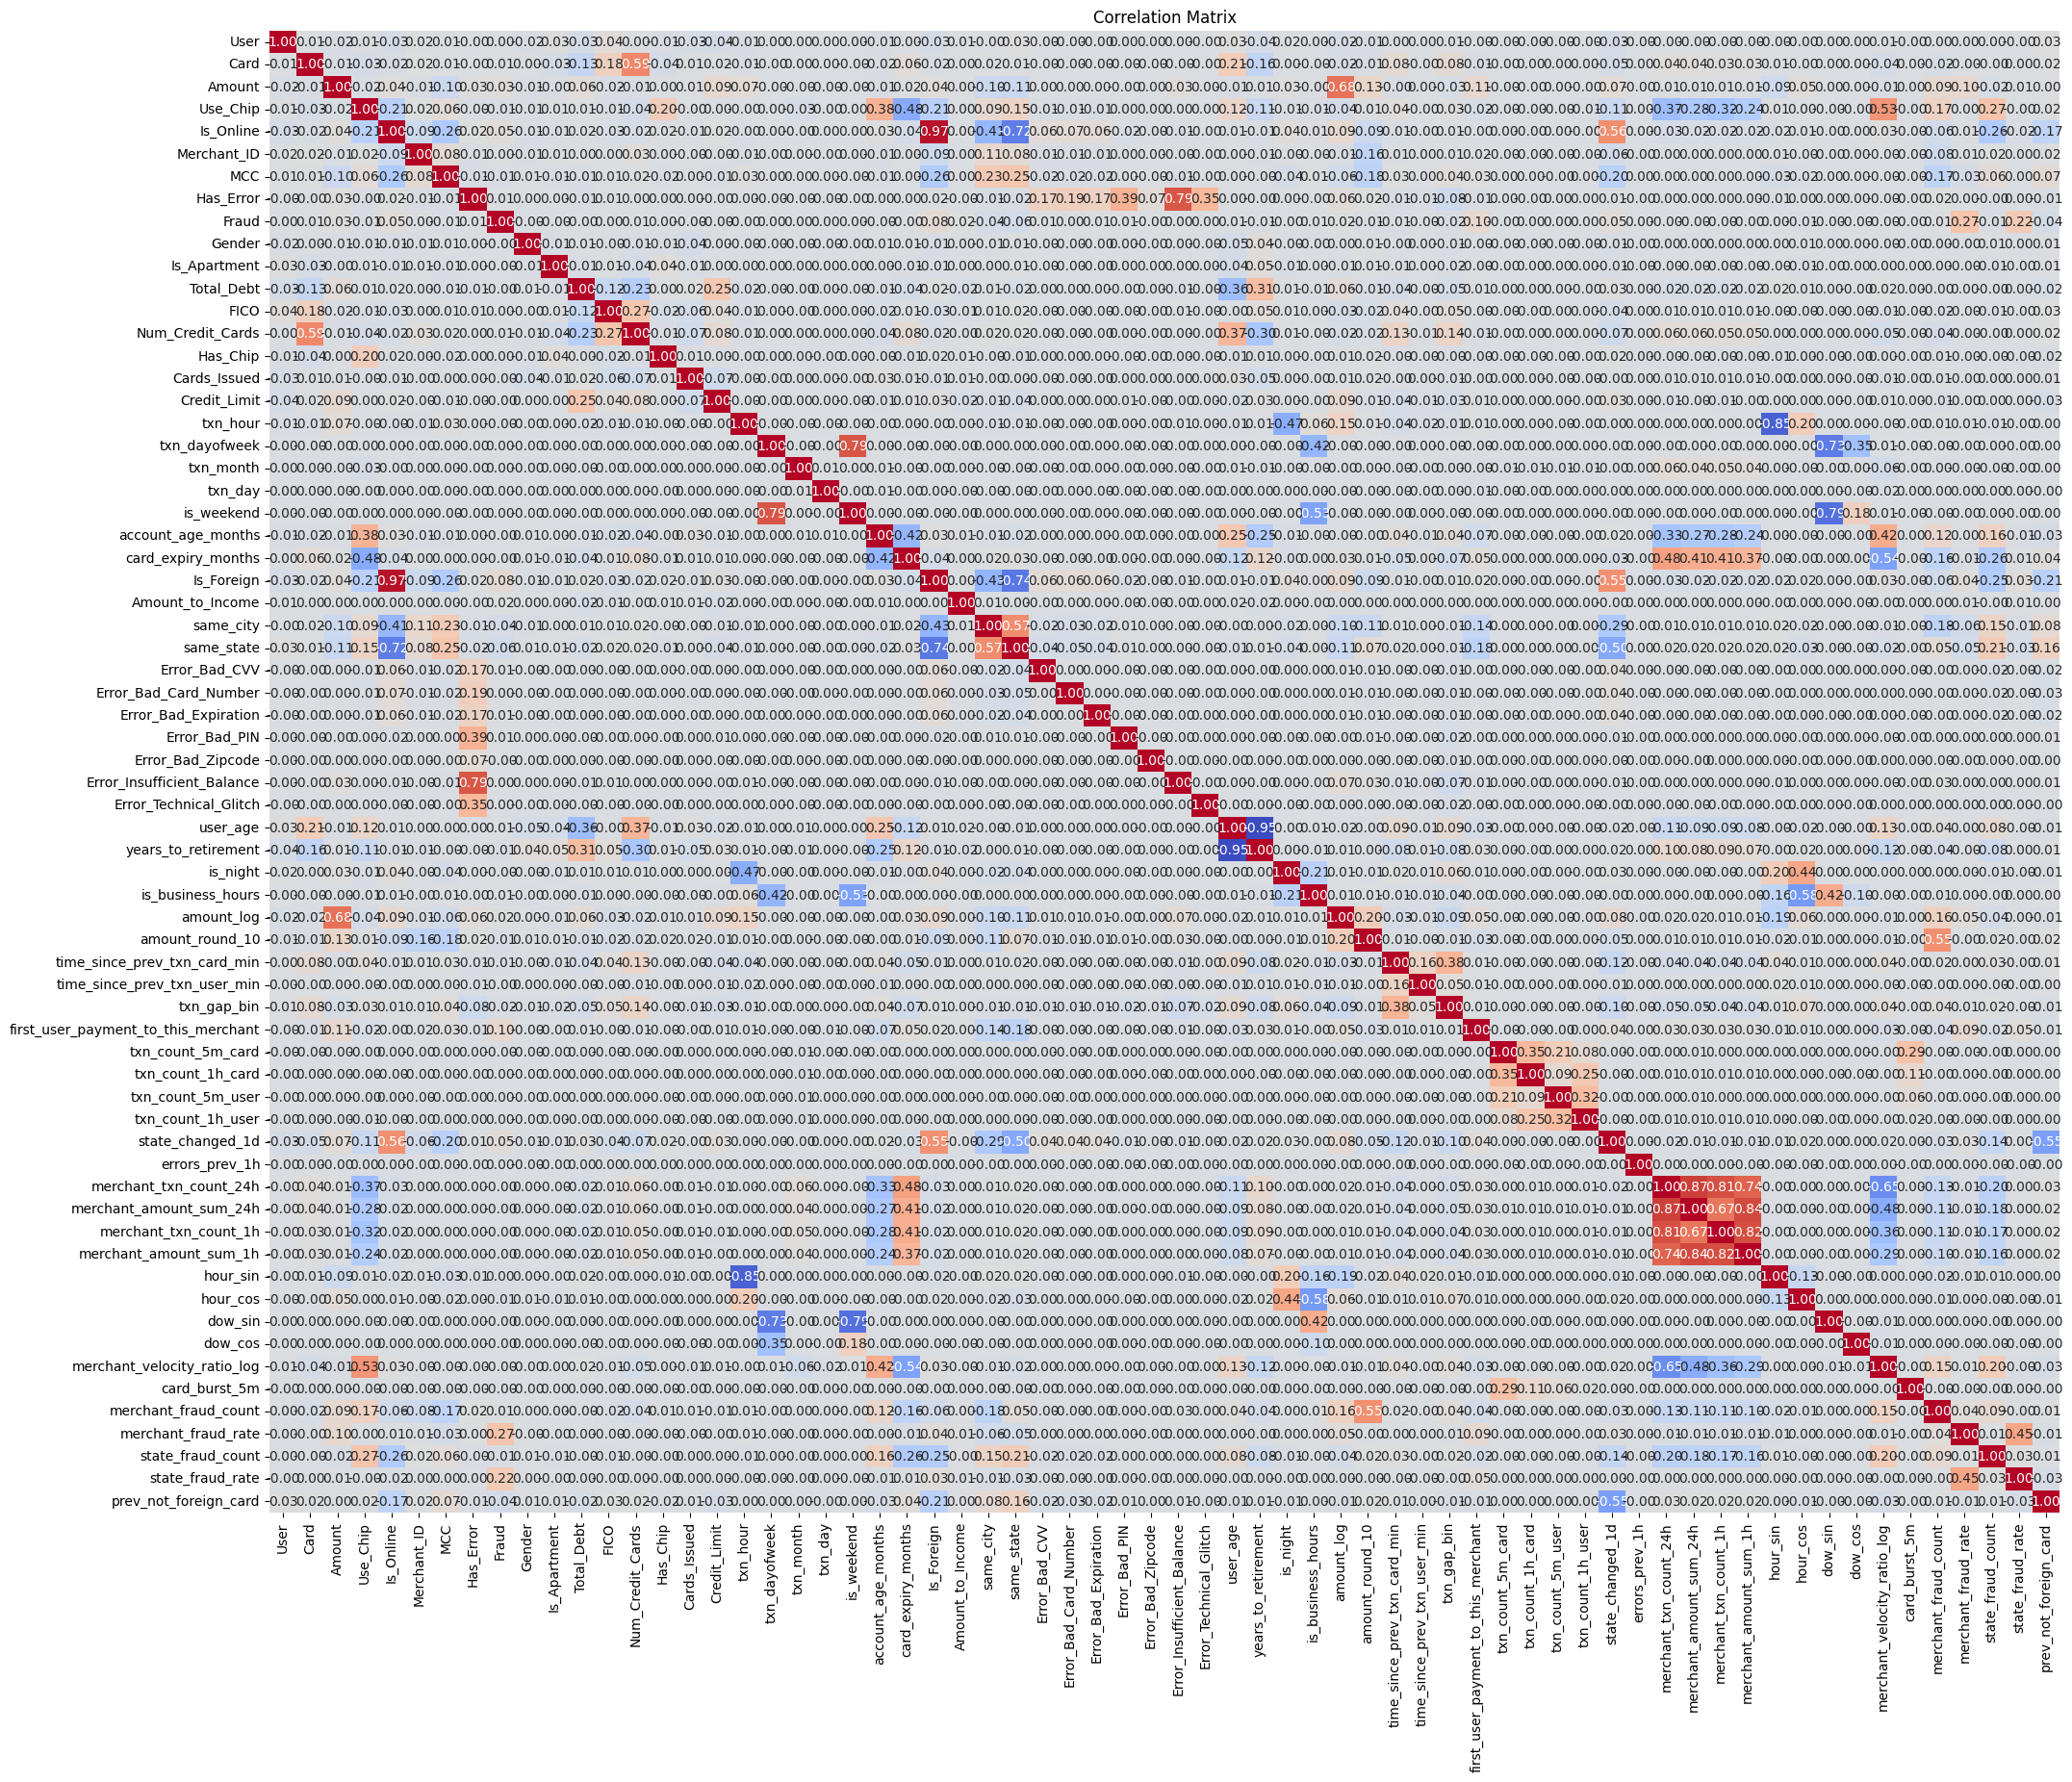

In [52]:
# Перед разбиением выборки проведём быструю проверку на мультиколлинеарность и коррреляцию с целевой переменной
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Correlation Matrix')
plt.show()


In [53]:
# Выводим список корреляция выше 0.9 (по абсолютному значению)
corr_numeric = data.corr(numeric_only=True)
high_corr = (
    corr_numeric
    .where(np.triu(np.ones(corr_numeric.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature_1','Feature_2','Correlation']

high_corr = high_corr[high_corr['Correlation'].abs() > 0.9]

display(high_corr.sort_values('Correlation', ascending=False))

,Feature_1,Feature_2,Correlation
273,Is_Online,Is_Foreign,0.971221
1680,user_age,years_to_retirement,-0.947482


In [54]:
# Особенность датасета в том, что почти все он-лайн транзакции - заграничные. 
# Заменим признак заграничной транзакции на заграничная офф-лайн транзакций
data['is_foreign_offline'] = (
    (data['Is_Foreign'] == 1) & (data['Is_Online'] == 0)
).astype('int8')
# Проверяем распределение признака
data['is_foreign_offline'].value_counts()

is_foreign_offline
0    22999621
1      142596
Name: count, dtype: int64

In [55]:
# Удаляем признак заграничной транзакции, он нам больше не нужен, а новый признак более информативный
data.drop(columns=['Is_Foreign'], inplace=True)
# Удаляем признак остатка до пенсии как слишком скоррелированного с возрастом и неинформативного
data.drop(columns=['years_to_retirement'], inplace=True)
# Удаляем менее полезные признаки
data.drop(columns=['same_city', 'same_state'], inplace=True)
# Удаляем лишние признаки числа транзакций (у нас есть rate, count нам не нужен) - это полезно, т.к. "старые" мерчанты будут иметь слишком высокий 
# count, а новый признак с rate будет более информативным для модели.
data.drop(columns=['merchant_fraud_count', 'state_fraud_count'], inplace=True)


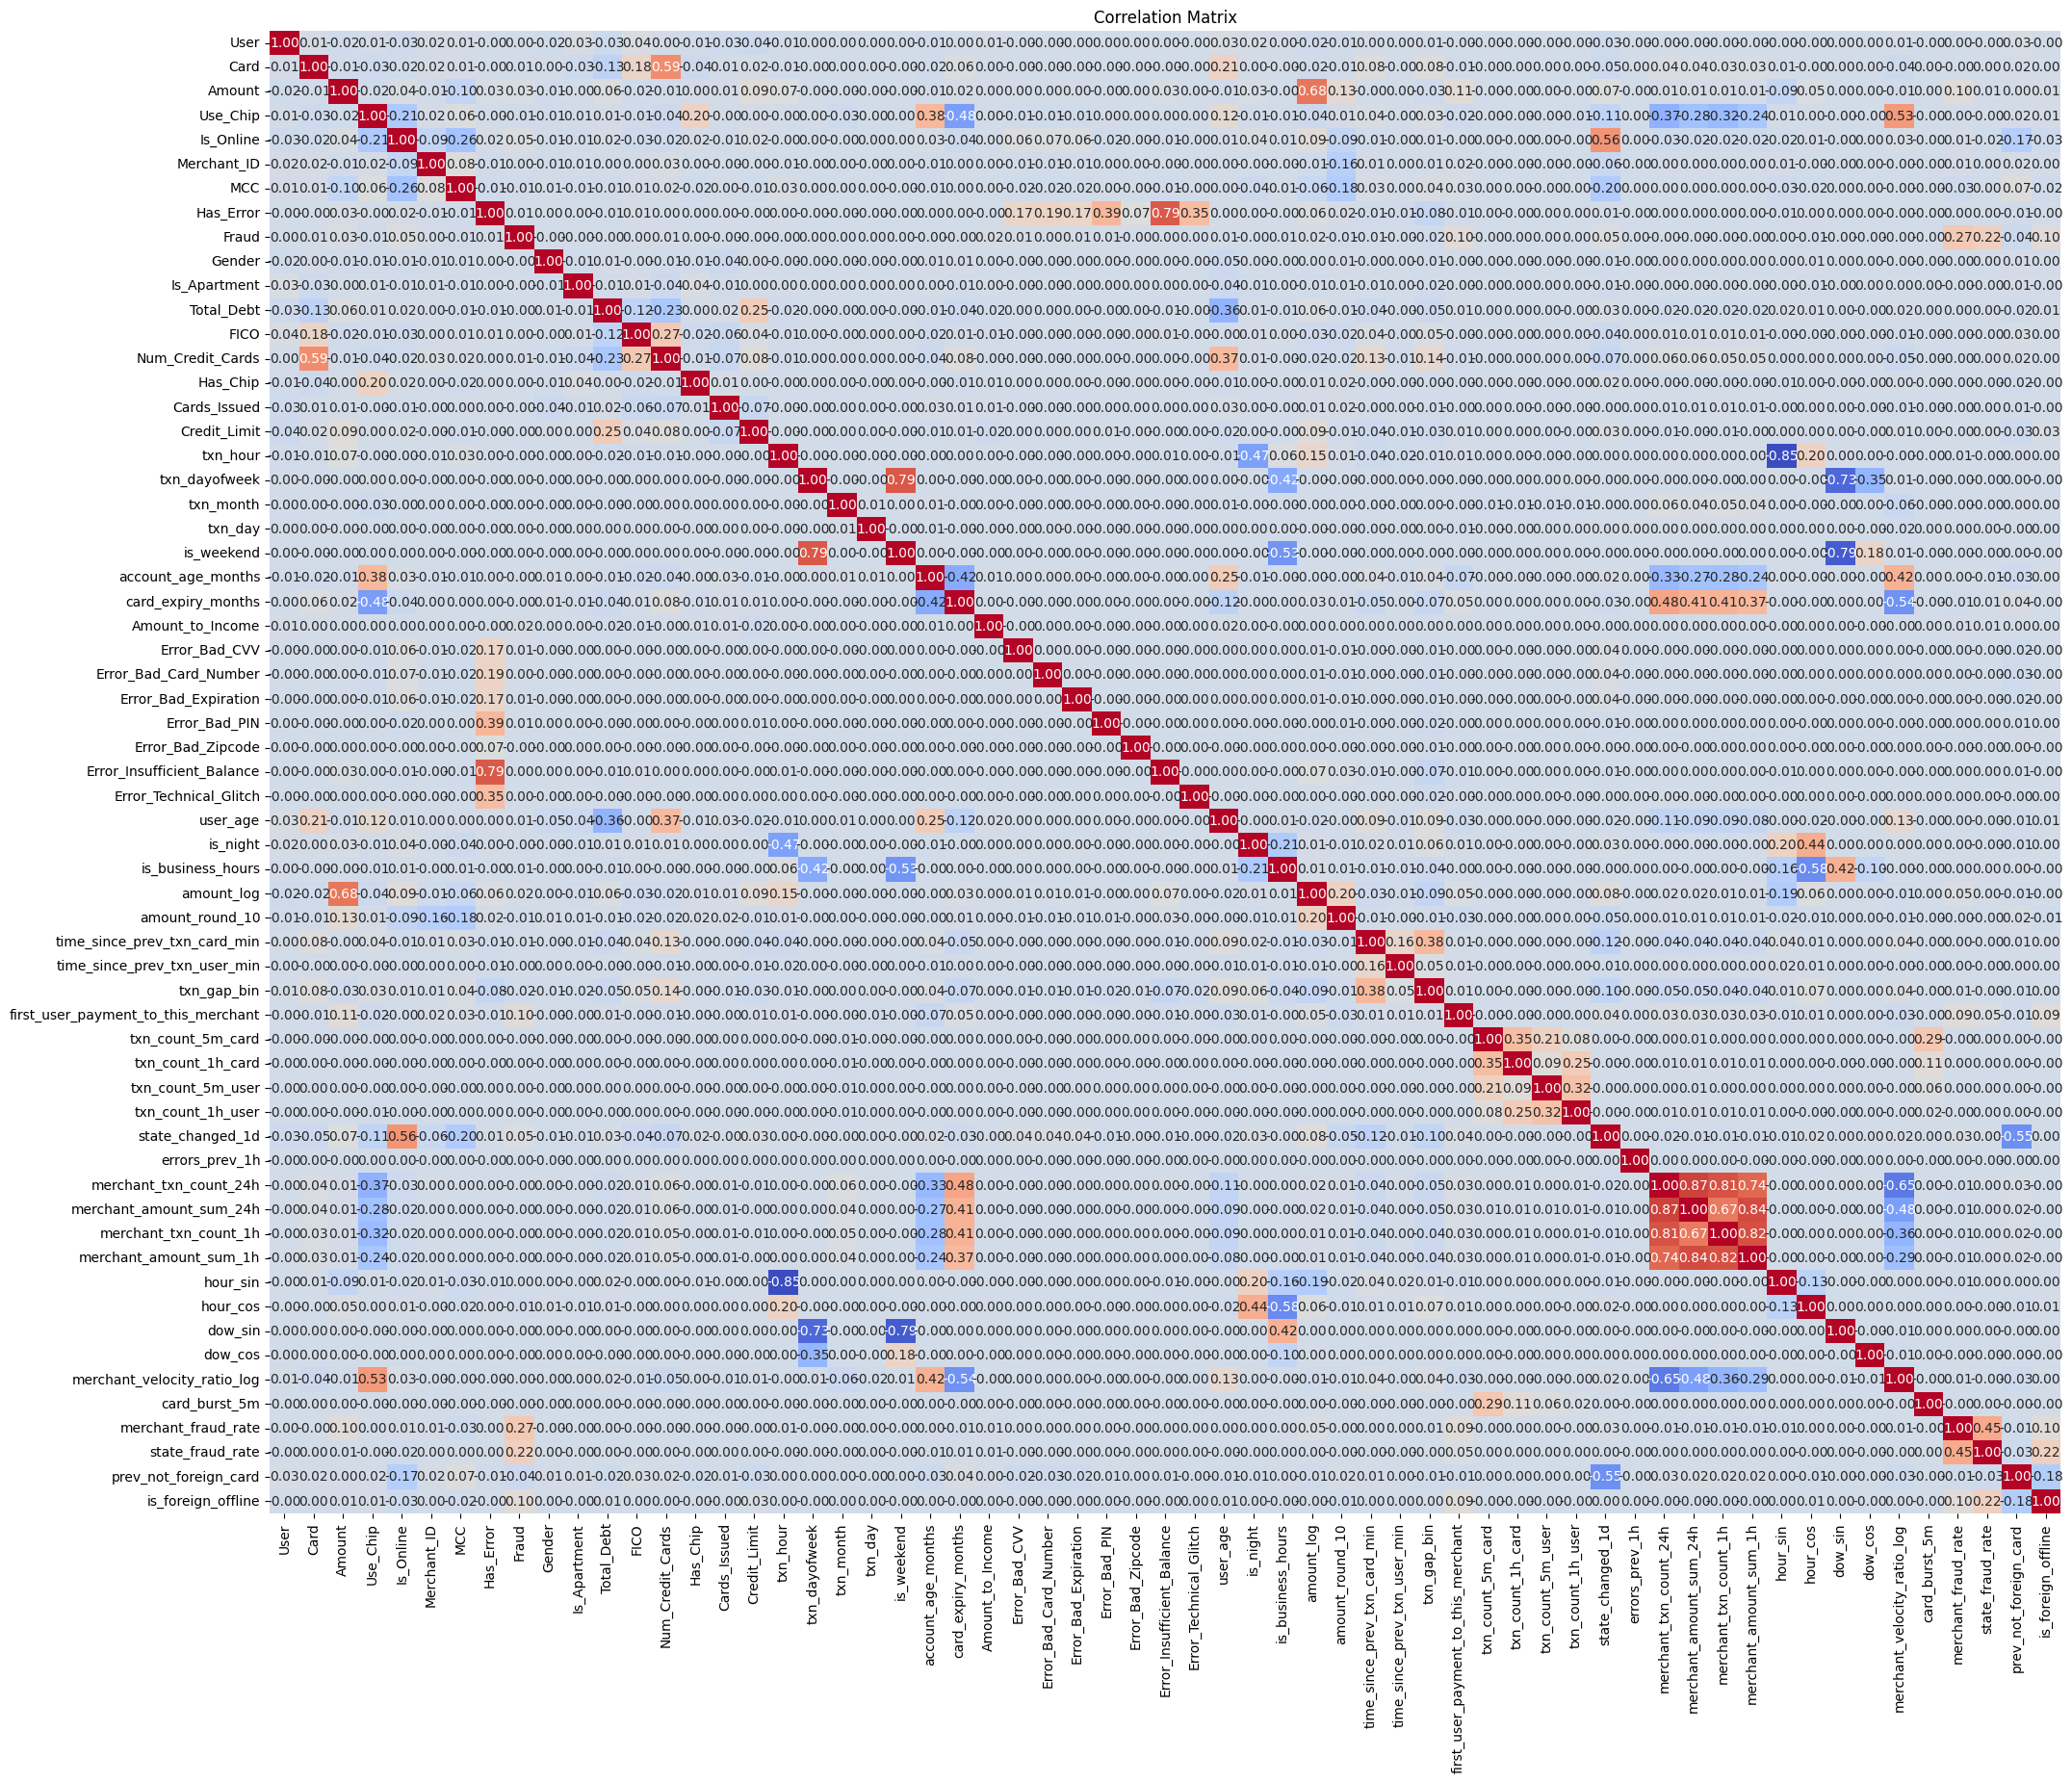

In [56]:
# Повторим проверку
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Correlation Matrix')
plt.show()

## 3.6 Проверяем сдвиг распределения данных по времени

После того, как мы создали все признаки, необходимо проверить, не получилось ли так, что какие-то признаки очень характерны для определённого периода времени - т.е., не слишком ли "широкий" у нас датасет. 

In [57]:
from pandas.api.types import (
    is_datetime64_any_dtype,
    is_numeric_dtype,
    is_categorical_dtype,
    is_object_dtype,
    is_bool_dtype,
)

# 1. НАСТРОЙКИ

CHUNK_SIZE = 1_000_000
TREAT_LOW_CARD_NUMERIC_AS_CATEGORICAL = True
LOW_CARD_THRESHOLD = 20
NUMERIC_PSI_BINS = 10
TOP_N_CATEGORIES_TO_SHOW = 15
EPS = 1e-10

# 2. ПОДГОТОВКА

df = data.copy()
#df = data_2015_2019.copy() # тут мы проверяли результаты - и они оказались хорошими

df["million_chunk"] = (np.arange(len(df)) // CHUNK_SIZE) + 1

print("Количество строк:", len(df))
print("Количество миллионов/чанков:", df["million_chunk"].nunique())
print(df["million_chunk"].value_counts().sort_index())

# 3. ОПРЕДЕЛЕНИЕ ТИПОВ ПРИЗНАКОВ

feature_cols = [c for c in df.columns if c != "million_chunk"]

timestamp_cols = [c for c in feature_cols if is_datetime64_any_dtype(df[c])]
feature_cols_wo_time = [c for c in feature_cols if c not in timestamp_cols]

cat_cols = [
    c for c in feature_cols_wo_time
    if is_categorical_dtype(df[c]) or is_object_dtype(df[c]) or is_bool_dtype(df[c])
]

num_cols = [
    c for c in feature_cols_wo_time
    if is_numeric_dtype(df[c])
]

if TREAT_LOW_CARD_NUMERIC_AS_CATEGORICAL:
    low_card_num_cols = [
        c for c in num_cols
        if df[c].nunique(dropna=False) <= LOW_CARD_THRESHOLD
    ]
    cat_cols = sorted(list(set(cat_cols + low_card_num_cols)))
    num_cols = [c for c in num_cols if c not in low_card_num_cols]

print(f"\nTimestamp columns: {timestamp_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {num_cols}")

Количество строк: 23142217
Количество миллионов/чанков: 24
million_chunk
1     1000000
2     1000000
3     1000000
4     1000000
5     1000000
6     1000000
7     1000000
8     1000000
9     1000000
10    1000000
11    1000000
12    1000000
13    1000000
14    1000000
15    1000000
16    1000000
17    1000000
18    1000000
19    1000000
20    1000000
21    1000000
22    1000000
23    1000000
24     142217
Name: count, dtype: int64


C:\Users\dmytr\AppData\Local\Temp\ipykernel_36364\2628912316.py:38: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(df[c]) or is_object_dtype(df[c]) or is_bool_dtype(df[c])



Timestamp columns: ['Timestamp']
Categorical columns (41): ['Card', 'Card_Brand', 'Card_Type', 'Cards_Issued', 'Error_Bad_CVV', 'Error_Bad_Card_Number', 'Error_Bad_Expiration', 'Error_Bad_PIN', 'Error_Bad_Zipcode', 'Error_Insufficient_Balance', 'Error_Technical_Glitch', 'Fraud', 'Gender', 'Has_Chip', 'Has_Error', 'Is_Apartment', 'Is_Online', 'Merchant_State', 'Num_Credit_Cards', 'Use_Chip', 'amount_round_10', 'card_burst_5m', 'dow_cos', 'dow_sin', 'errors_prev_1h', 'first_user_payment_to_this_merchant', 'hour_cos', 'hour_sin', 'is_business_hours', 'is_foreign_offline', 'is_night', 'is_weekend', 'prev_not_foreign_card', 'state_changed_1d', 'txn_count_1h_card', 'txn_count_1h_user', 'txn_count_5m_card', 'txn_count_5m_user', 'txn_dayofweek', 'txn_gap_bin', 'txn_month']
Numeric columns (23): ['User', 'Amount', 'Merchant_ID', 'MCC', 'Total_Debt', 'FICO', 'Credit_Limit', 'txn_hour', 'txn_day', 'account_age_months', 'card_expiry_months', 'Amount_to_Income', 'user_age', 'amount_log', 'time_sin

In [58]:
# 4. СЛУЖЕБНЫЕ ФУНКЦИИ

def psi_numeric(expected, actual, bins=10):
    """
    PSI для числового признака.
    expected = базовый миллион
    actual   = текущий миллион
    """
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if len(expected) == 0 or len(actual) == 0:
        return np.nan

    # Бины строим по expected
    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))

    # Если распределение почти константное
    if len(breakpoints) < 3:
        return 0.0

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    expected_dist = expected_bins.value_counts(normalize=True, sort=False)
    actual_dist = actual_bins.value_counts(normalize=True, sort=False)

    # выравниваем индексы
    idx = expected_dist.index.union(actual_dist.index)
    expected_dist = expected_dist.reindex(idx, fill_value=0.0) + EPS
    actual_dist = actual_dist.reindex(idx, fill_value=0.0) + EPS

    psi = np.sum((actual_dist - expected_dist) * np.log(actual_dist / expected_dist))
    return float(psi)


def get_categorical_distribution(series):
    """
    Возвращает распределение категорий с учетом NaN как отдельной категории.
    """
    s = series.astype("object").where(~series.isna(), "__MISSING__")
    return s.value_counts(normalize=True, dropna=False)


def js_divergence_from_distributions(p, q):
    """
    Jensen-Shannon divergence для двух распределений.
    """
    idx = p.index.union(q.index)
    p = p.reindex(idx, fill_value=0.0).astype(float) + EPS
    q = q.reindex(idx, fill_value=0.0).astype(float) + EPS
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    js = 0.5 * entropy(p, m) + 0.5 * entropy(q, m)
    return float(js)


def tvd_from_distributions(p, q):
    """
    Total Variation Distance.
    """
    idx = p.index.union(q.index)
    p = p.reindex(idx, fill_value=0.0).astype(float)
    q = q.reindex(idx, fill_value=0.0).astype(float)
    return float(0.5 * np.abs(p - q).sum())




In [59]:

# 5. ИНФО ПО ЧАНКАМ

chunk_info = (
    df.groupby("million_chunk")
      .agg(
          rows=("million_chunk", "size"),
          ts_min=("Timestamp", "min"),
          ts_max=("Timestamp", "max"),
          fraud_rate=("Fraud", "mean")
      )
      .reset_index()
)

display(chunk_info)



# 6. ЧИСЛОВЫЕ ПРИЗНАКИ:


numeric_stats = []

for chunk_id, part in df.groupby("million_chunk", sort=True):
    for col in num_cols:
        s = part[col].replace([np.inf, -np.inf], np.nan)

        numeric_stats.append({
            "million_chunk": chunk_id,
            "feature": col,
            "count": s.notna().sum(),
            "missing_rate": s.isna().mean(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p01": s.quantile(0.01),
            "p05": s.quantile(0.05),
            "p25": s.quantile(0.25),
            "median": s.quantile(0.50),
            "p75": s.quantile(0.75),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max(),
        })

numeric_stats_df = pd.DataFrame(numeric_stats)
display(numeric_stats_df.head())


# 7. PSI относительно 1-го миллиона + PSI относительно предыдущего миллиона

numeric_psi_rows = []

grouped_chunks = {k: v for k, v in df.groupby("million_chunk", sort=True)}
chunk_ids = sorted(grouped_chunks.keys())

for col in num_cols:
    base_series = grouped_chunks[chunk_ids[0]][col]

    prev_series = None
    for chunk_id in chunk_ids:
        current_series = grouped_chunks[chunk_id][col]

        psi_vs_first = psi_numeric(base_series, current_series, bins=NUMERIC_PSI_BINS)

        if prev_series is None:
            psi_vs_prev = np.nan
        else:
            psi_vs_prev = psi_numeric(prev_series, current_series, bins=NUMERIC_PSI_BINS)

        numeric_psi_rows.append({
            "feature": col,
            "million_chunk": chunk_id,
            "psi_vs_first_chunk": psi_vs_first,
            "psi_vs_prev_chunk": psi_vs_prev
        })

        prev_series = current_series

numeric_psi_df = pd.DataFrame(numeric_psi_rows)
display(numeric_psi_df.head())



# 8. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:

categorical_drift_rows = []
categorical_top_shares = []

for col in cat_cols:
    base_dist = get_categorical_distribution(grouped_chunks[chunk_ids[0]][col])

    prev_dist = None
    for chunk_id in chunk_ids:
        current_dist = get_categorical_distribution(grouped_chunks[chunk_id][col])

        js_vs_first = js_divergence_from_distributions(base_dist, current_dist)
        tvd_vs_first = tvd_from_distributions(base_dist, current_dist)

        if prev_dist is None:
            js_vs_prev = np.nan
            tvd_vs_prev = np.nan
        else:
            js_vs_prev = js_divergence_from_distributions(prev_dist, current_dist)
            tvd_vs_prev = tvd_from_distributions(prev_dist, current_dist)

        categorical_drift_rows.append({
            "feature": col,
            "million_chunk": chunk_id,
            "n_unique_in_chunk": grouped_chunks[chunk_id][col].nunique(dropna=False),
            "missing_rate": grouped_chunks[chunk_id][col].isna().mean(),
            "js_vs_first_chunk": js_vs_first,
            "tvd_vs_first_chunk": tvd_vs_first,
            "js_vs_prev_chunk": js_vs_prev,
            "tvd_vs_prev_chunk": tvd_vs_prev,
        })

        # сохраним топ-категории для просмотра
        top_dist = current_dist.sort_values(ascending=False).head(TOP_N_CATEGORIES_TO_SHOW)
        for cat_value, share in top_dist.items():
            categorical_top_shares.append({
                "feature": col,
                "million_chunk": chunk_id,
                "category": cat_value,
                "share": share
            })

        prev_dist = current_dist

categorical_drift_df = pd.DataFrame(categorical_drift_rows)
categorical_top_shares_df = pd.DataFrame(categorical_top_shares)

display(categorical_drift_df.head())
display(categorical_top_shares_df.head())




,million_chunk,rows,ts_min,ts_max,fraud_rate
0,1,1000000,1991-01-02 07:10:00,2002-11-18 10:25:00,0.000663
1,2,1000000,2002-11-18 10:26:00,2004-12-04 16:31:00,0.00094
2,3,1000000,2004-12-04 16:32:00,2006-04-23 08:01:00,0.000786
3,4,1000000,2006-04-23 08:01:00,2007-05-29 13:23:00,0.000926
4,5,1000000,2007-05-29 13:23:00,2008-05-07 13:13:00,0.002433
5,6,1000000,2008-05-07 13:13:00,2009-03-08 13:34:00,0.003141
6,7,1000000,2009-03-08 13:34:00,2009-12-16 06:16:00,0.000462
7,8,1000000,2009-12-16 06:16:00,2010-09-03 16:30:00,0.00257
8,9,1000000,2010-09-03 16:30:00,2011-05-11 11:52:00,0.001154
9,10,1000000,2011-05-11 11:52:00,2012-01-09 12:27:00,0.00004


,million_chunk,feature,count,missing_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max
0,1,User,1000000,0,1028.458317,558.576443,0,19,89,513,1062,1497,1893,1955,1997
1,1,Amount,1000000,0,55.964287,77.763741,0,0.74,1.96,13.63,39.98,74.580002,154.960007,339,6261.689941
2,1,Merchant_ID,1000000,0,47936.138712,26299.334051,3,2611,10882,25887,46284,68671,93006,99227,100340
3,1,MCC,1000000,0,5573.213192,903.017222,1711,3596,4121,5300,5499,5813,7538,8099,9402
4,1,Total_Debt,1000000,0,47980.566406,42894.453125,0,0,396,11245,41173,75783,124139,197377,247623


,feature,million_chunk,psi_vs_first_chunk,psi_vs_prev_chunk
0,User,1,0,NaN
1,User,2,0.016457,0.016457
2,User,3,0.029434,0.004571
3,User,4,0.03377,0.002439
4,User,5,0.033361,0.00157


,feature,million_chunk,n_unique_in_chunk,missing_rate,js_vs_first_chunk,tvd_vs_first_chunk,js_vs_prev_chunk,tvd_vs_prev_chunk
0,Card,1,8,0,0,0,NaN,NaN
1,Card,2,8,0,0.002948,0.052683,0.002948,0.052683
2,Card,3,9,0,0.004149,0.055785,0.000396,0.021364
3,Card,4,9,0,0.004899,0.06872,0.000452,0.020253
4,Card,5,9,0,0.006216,0.080692,0.000262,0.019894


,feature,million_chunk,category,share
0,Card,1,0,0.287247
1,Card,1,1,0.252303
2,Card,1,2,0.166858
3,Card,1,3,0.134798
4,Card,1,4,0.107823


In [60]:

# 9. СВОДКИ: КАКИЕ ПРИЗНАКИ ДРЕЙФУЮТ СИЛЬНЕЕ ВСЕГО

numeric_drift_summary = (
    numeric_psi_df.groupby("feature")
    .agg(
        max_psi_vs_first=("psi_vs_first_chunk", "max"),
        mean_psi_vs_first=("psi_vs_first_chunk", "mean"),
        max_psi_vs_prev=("psi_vs_prev_chunk", "max"),
        mean_psi_vs_prev=("psi_vs_prev_chunk", "mean"),
    )
    .sort_values("max_psi_vs_first", ascending=False)
    .reset_index()
)

categorical_drift_summary = (
    categorical_drift_df.groupby("feature")
    .agg(
        max_js_vs_first=("js_vs_first_chunk", "max"),
        mean_js_vs_first=("js_vs_first_chunk", "mean"),
        max_tvd_vs_first=("tvd_vs_first_chunk", "max"),
        mean_tvd_vs_first=("tvd_vs_first_chunk", "mean"),
        max_js_vs_prev=("js_vs_prev_chunk", "max"),
        max_tvd_vs_prev=("tvd_vs_prev_chunk", "max"),
    )
    .sort_values("max_tvd_vs_first", ascending=False)
    .reset_index()
)

print("\n=== Numeric drift summary ===")
display(numeric_drift_summary)

print("\n=== Categorical drift summary ===")
display(categorical_drift_summary)






=== Numeric drift summary ===


,feature,max_psi_vs_first,mean_psi_vs_first,max_psi_vs_prev,mean_psi_vs_prev
0,card_expiry_months,20.706395,17.574131,6.971823,0.811982
1,merchant_txn_count_24h,20.630738,10.425345,11.551232,1.623585
2,merchant_velocity_ratio_log,19.635808,4.360258,1.711279,0.254979
3,merchant_amount_sum_24h,19.395569,10.907786,7.46726,1.105265
4,merchant_txn_count_1h,14.680375,5.25457,2.760677,0.376964
5,merchant_amount_sum_1h,6.77201,3.057234,2.066758,0.388895
6,state_fraud_rate,2.64669,1.825608,1.397404,0.294192
7,account_age_months,2.547568,1.258036,0.294703,0.03339
8,txn_day,1.823992,0.078613,2.026959,0.095733
9,merchant_fraud_rate,0.529309,0.334597,0.141833,0.040125



=== Categorical drift summary ===


,feature,max_js_vs_first,mean_js_vs_first,max_tvd_vs_first,mean_tvd_vs_first,max_js_vs_prev,max_tvd_vs_prev
0,txn_month,0.565129,0.114645,0.930917,0.294361,0.652545,0.984261
1,Use_Chip,0.34322,0.132011,0.701642,0.272437,0.109478,0.458178
2,Num_Credit_Cards,0.045704,0.018238,0.236053,0.133628,0.003944,0.07629
3,Merchant_State,0.028889,0.024215,0.18085,0.161925,0.010716,0.110473
4,txn_gap_bin,0.02271,0.016573,0.15613,0.123641,0.00089,0.025537
5,Card,0.020747,0.009842,0.145814,0.096014,0.002948,0.052683
6,Is_Online,0.006799,0.004659,0.0688,0.053403,0.001021,0.023889
7,prev_not_foreign_card,0.00638,0.004449,0.068381,0.053692,0.000969,0.024094
8,state_changed_1d,0.002873,0.002025,0.057544,0.046299,0.000712,0.027689
9,dow_sin,0.001862,0.000269,0.053048,0.017676,0.002526,0.063471


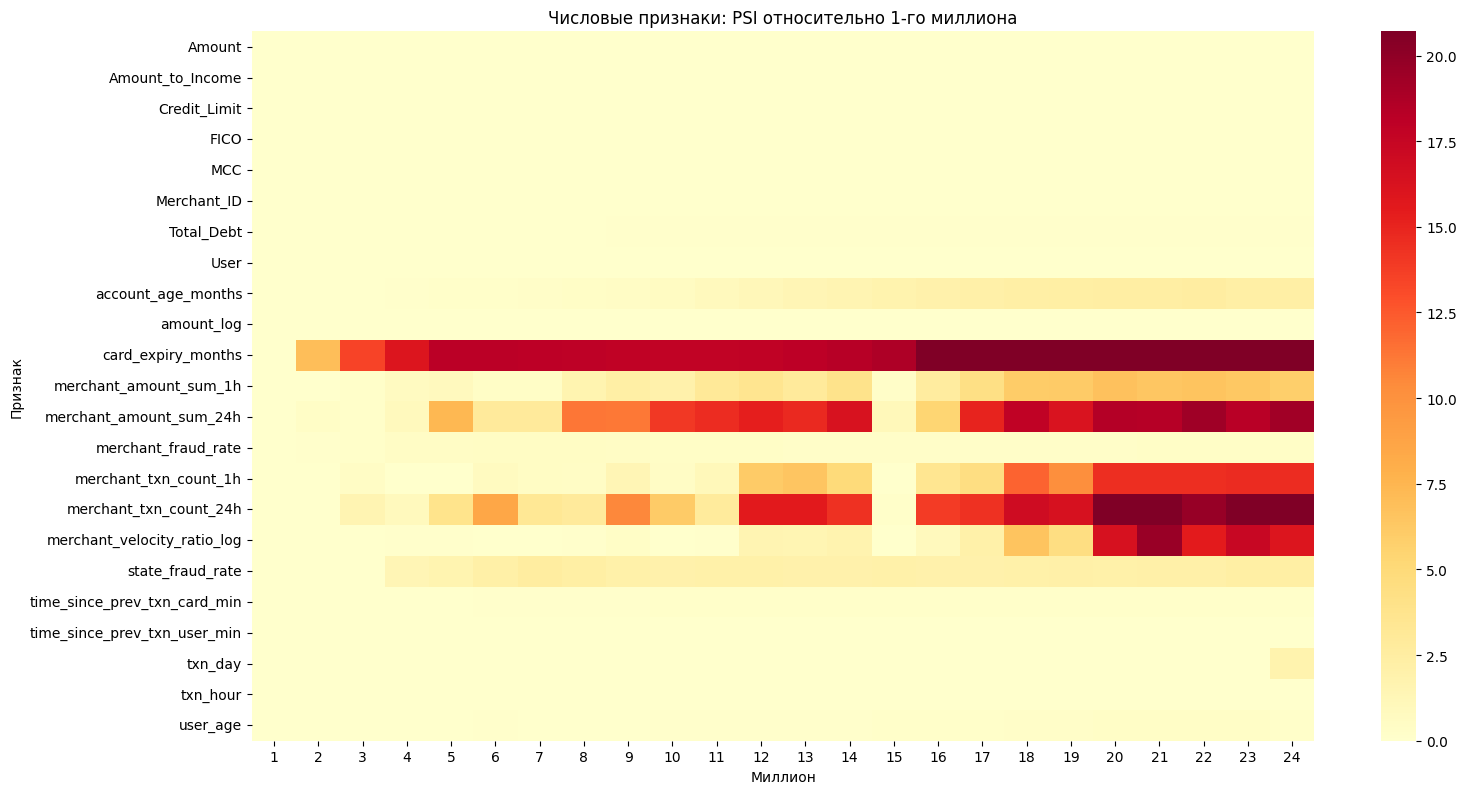

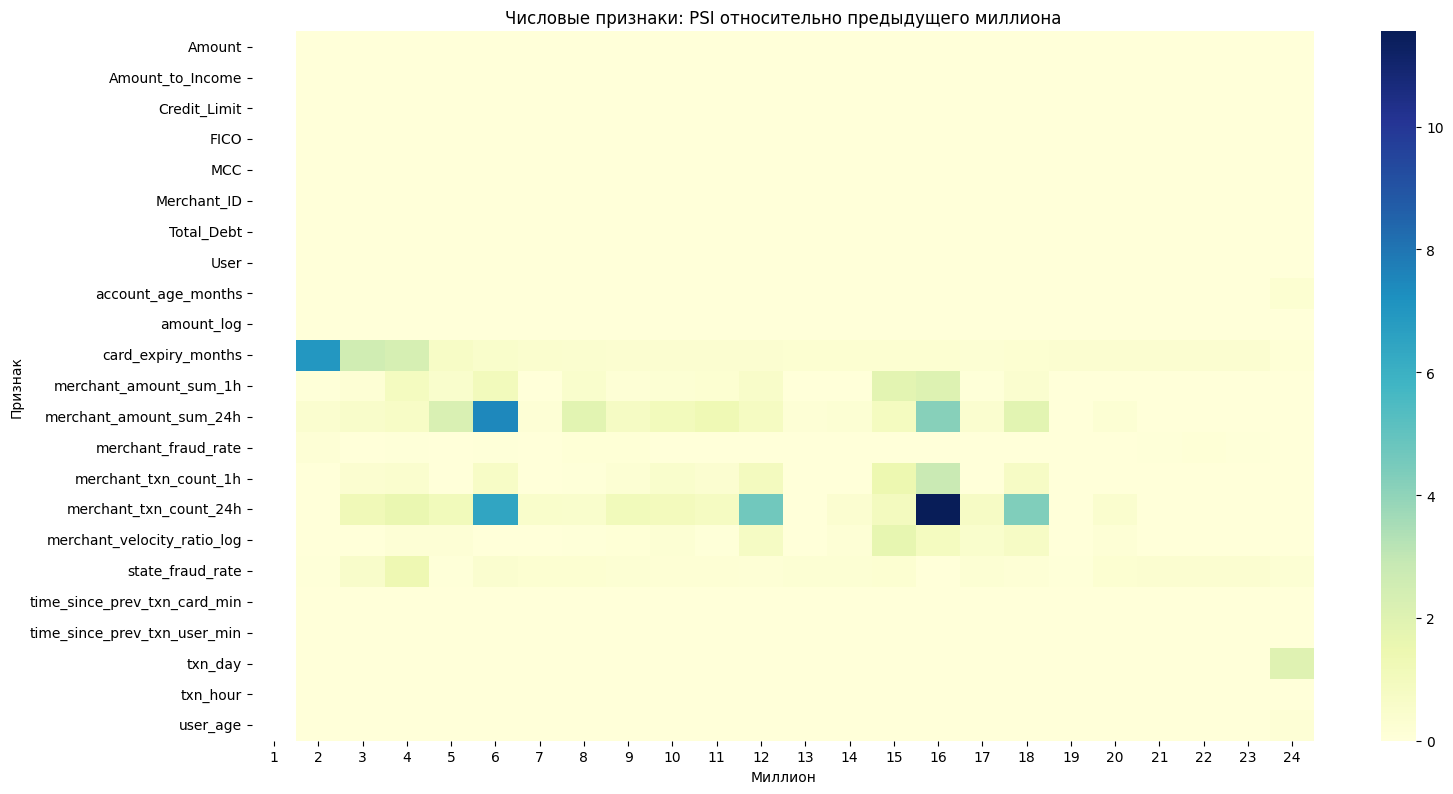

In [61]:
# 10. ТЕПЛОВЫЕ КАРТЫ ПО ЧИСЛОВЫМ ПРИЗНАКАМ

numeric_heatmap_first = numeric_psi_df.pivot(
    index="feature",
    columns="million_chunk",
    values="psi_vs_first_chunk"
)

numeric_heatmap_prev = numeric_psi_df.pivot(
    index="feature",
    columns="million_chunk",
    values="psi_vs_prev_chunk"
)

plt.figure(figsize=(16, max(8, len(numeric_heatmap_first) * 0.35)))
sns.heatmap(numeric_heatmap_first, cmap="YlOrRd")
plt.title("Числовые признаки: PSI относительно 1-го миллиона")
plt.xlabel("Миллион")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, max(8, len(numeric_heatmap_prev) * 0.35)))
sns.heatmap(numeric_heatmap_prev, cmap="YlGnBu")
plt.title("Числовые признаки: PSI относительно предыдущего миллиона")
plt.xlabel("Миллион")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()





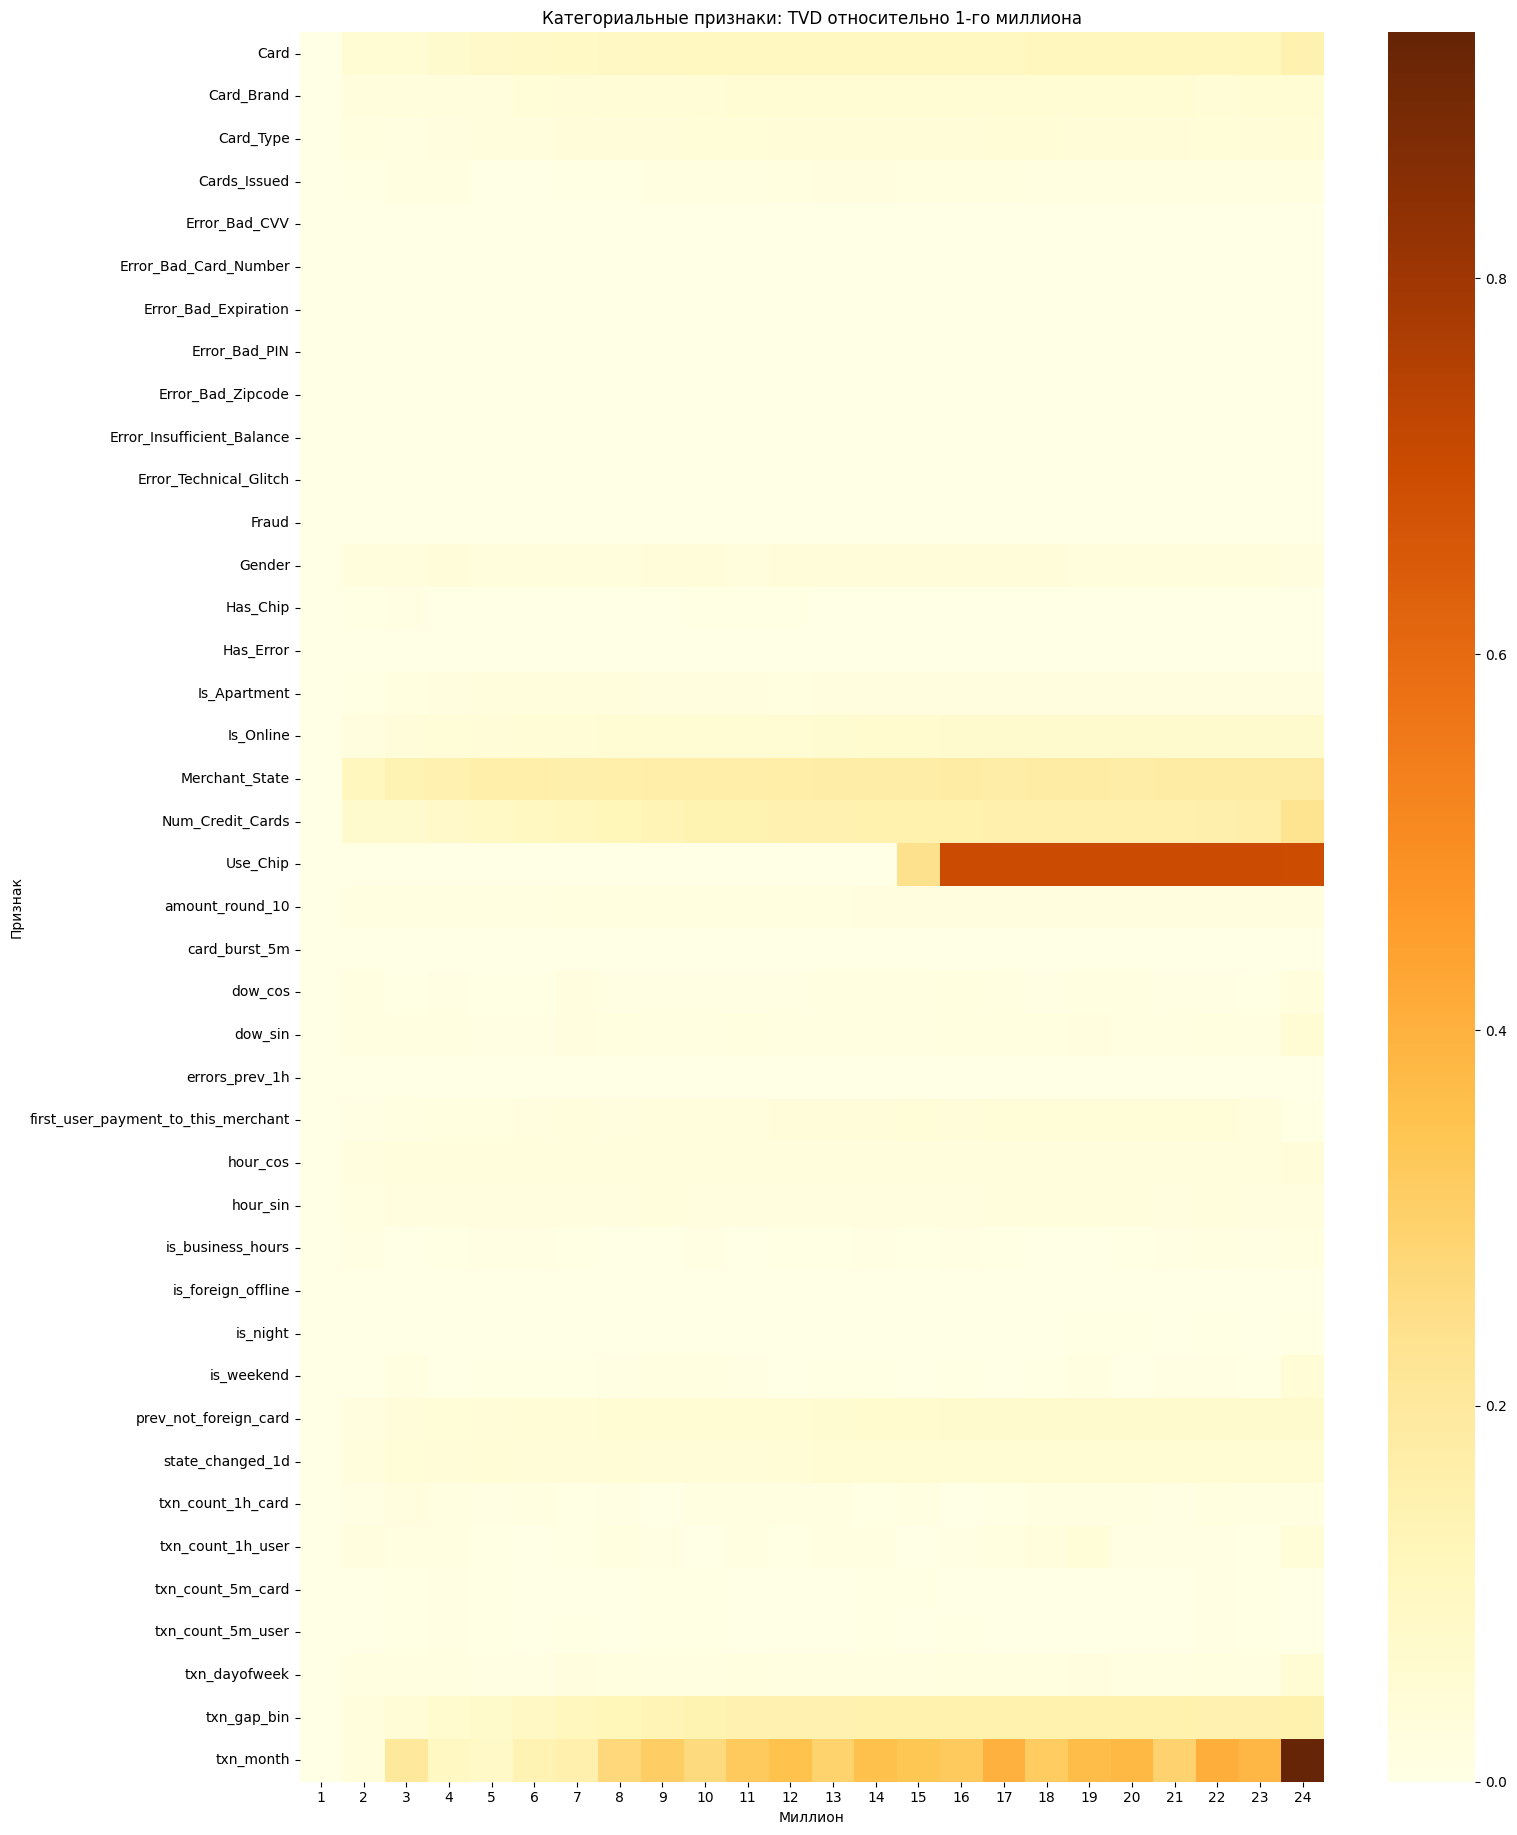

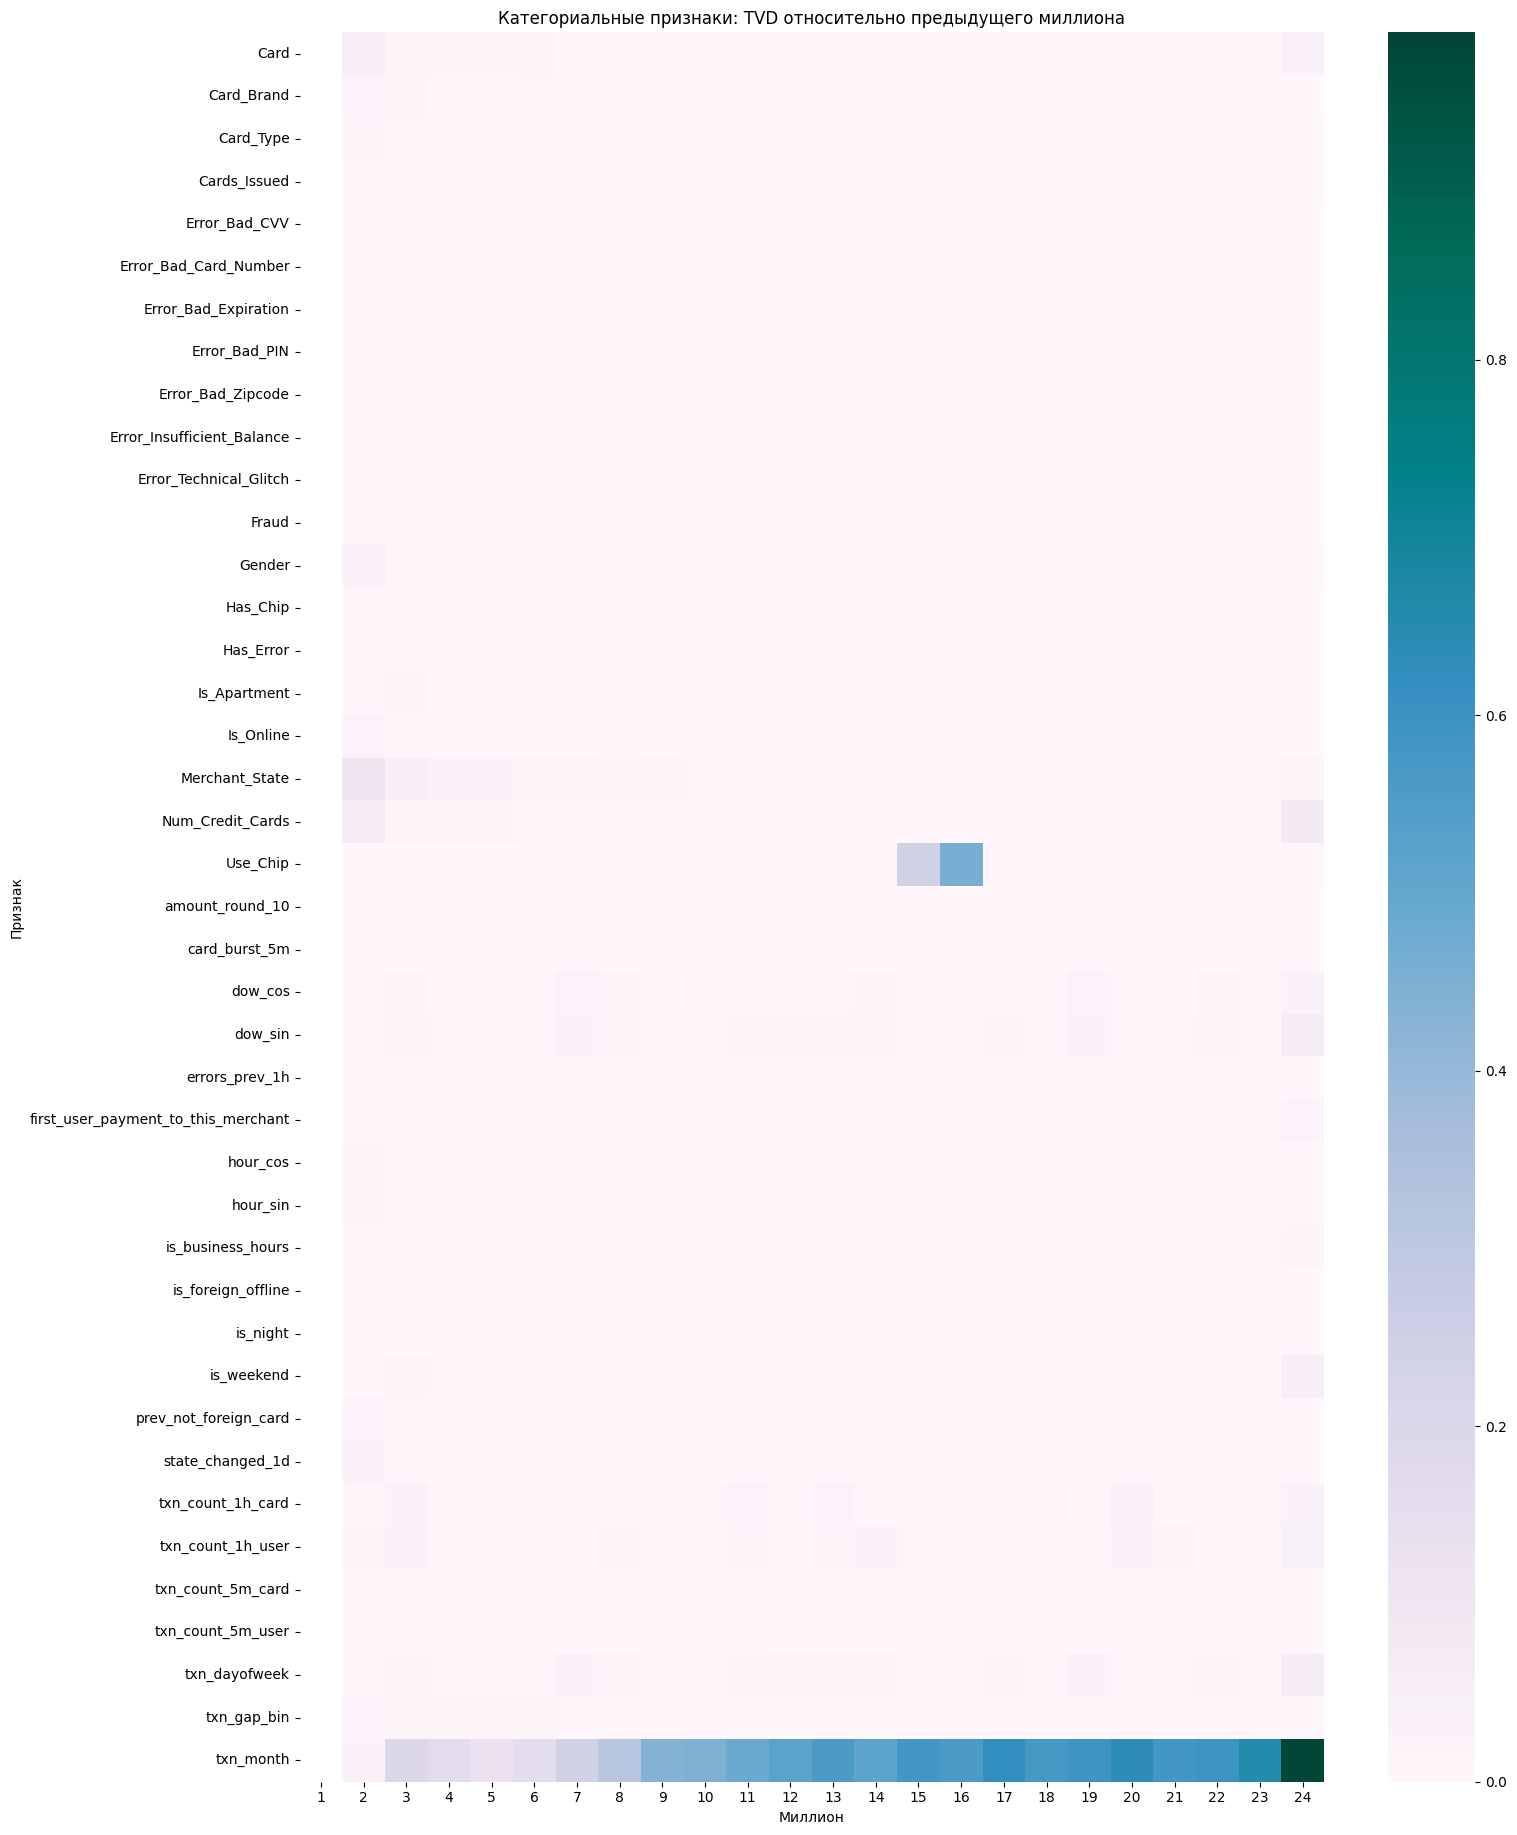

In [62]:
# 11. ТЕПЛОВЫЕ КАРТЫ ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ

categorical_heatmap_first = categorical_drift_df.pivot(
    index="feature",
    columns="million_chunk",
    values="tvd_vs_first_chunk"
)

categorical_heatmap_prev = categorical_drift_df.pivot(
    index="feature",
    columns="million_chunk",
    values="tvd_vs_prev_chunk"
)

plt.figure(figsize=(16, max(6, len(categorical_heatmap_first) * 0.45)))
sns.heatmap(categorical_heatmap_first, cmap="YlOrBr")
plt.title("Категориальные признаки: TVD относительно 1-го миллиона")
plt.xlabel("Миллион")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, max(6, len(categorical_heatmap_prev) * 0.45)))
sns.heatmap(categorical_heatmap_prev, cmap="PuBuGn")
plt.title("Категориальные признаки: TVD относительно предыдущего миллиона")
plt.xlabel("Миллион")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()




In [ ]:
# Самый большой дрейф
TOP_N = 15

print("\nТоп числовых признаков по max PSI vs first:")
display(numeric_drift_summary.head(TOP_N))

print("\nТоп категориальных признаков по max TVD vs first:")
display(categorical_drift_summary.head(TOP_N))


Топ числовых признаков по max PSI vs first:


,feature,max_psi_vs_first,mean_psi_vs_first,max_psi_vs_prev,mean_psi_vs_prev
0,card_expiry_months,20.706395,17.574131,6.971823,0.811982
1,merchant_txn_count_24h,20.630738,10.425345,11.551232,1.623585
2,merchant_velocity_ratio_log,19.635808,4.360258,1.711279,0.254979
3,merchant_amount_sum_24h,19.395569,10.907786,7.46726,1.105265
4,merchant_txn_count_1h,14.680375,5.25457,2.760677,0.376964
5,merchant_amount_sum_1h,6.77201,3.057234,2.066758,0.388895
6,state_fraud_rate,2.64669,1.825608,1.397404,0.294192
7,account_age_months,2.547568,1.258036,0.294703,0.03339
8,txn_day,1.823992,0.078613,2.026959,0.095733
9,merchant_fraud_rate,0.529309,0.334597,0.141833,0.040125



Топ категориальных признаков по max TVD vs first:


,feature,max_js_vs_first,mean_js_vs_first,max_tvd_vs_first,mean_tvd_vs_first,max_js_vs_prev,max_tvd_vs_prev
0,txn_month,0.565129,0.114645,0.930917,0.294361,0.652545,0.984261
1,Use_Chip,0.34322,0.132011,0.701642,0.272437,0.109478,0.458178
2,Num_Credit_Cards,0.045704,0.018238,0.236053,0.133628,0.003944,0.07629
3,Merchant_State,0.028889,0.024215,0.18085,0.161925,0.010716,0.110473
4,txn_gap_bin,0.02271,0.016573,0.15613,0.123641,0.00089,0.025537
5,Card,0.020747,0.009842,0.145814,0.096014,0.002948,0.052683
6,Is_Online,0.006799,0.004659,0.0688,0.053403,0.001021,0.023889
7,prev_not_foreign_card,0.00638,0.004449,0.068381,0.053692,0.000969,0.024094
8,state_changed_1d,0.002873,0.002025,0.057544,0.046299,0.000712,0.027689
9,dow_sin,0.001862,0.000269,0.053048,0.017676,0.002526,0.063471


Мы столкнулись с очень сложной проблемой - у нас есть фичи, которые сильно меняются со временем в силу того, что мир меняется (становится больше транзакций с чипом и больше он-лайн транзакций, суммы транзакций меняются т.к. с появлением мобильных транзакций стали чаще платиться мелкие суммы). Очень жаль терять огромный массив данных но, возможно, что мы рискуем обучить модель на устаревших даннх, что может привести к нестабильности или бесполезности моделей.
Судя по тепловым картам существенный "перелом" происходит на рубеже 15 000 000 записей. Это, примерно, с 2015 года. Попробуем взять срез 2015-2019 годы. 2020 год проигнорируем т.к. исходя из EDA там анормально мало фрода. 

In [64]:
# Признак малополезный и сильно меняется, создаёт, фактически, дополнительный счётчик времени, который может запутать модель.
data.drop(columns=['card_expiry_months'], inplace=True)

In [65]:
# Также удалим признак txn_month - ранее он не показывал высокой корреляции с целевой переменной, а теперь мы видим, что он сильно дрейфует.
data.drop(columns=['txn_month'], inplace=True)  

## 3.7 Разбиение датасета

Мы будем пробовать различные методы - регресиию, деревья и попробуем Deep Learning. По-этому нам понадобится два отдельных набора. Так для регрессии нам понадобится энкодинг категориальных признаков и удаление ряда признаков, а для деревьев подобное не понадобится. По-этому сейчас мы разобьём датасет на 2 отдельных - для линейных моделей (DL будем считать линейной моделью, т.к. там тоже используются числовые признаки) и для моделей деревьев.

In [66]:
# Оставляем 2015-2019 годы для работы.
mask = data['Timestamp'].between('2015-01-01', '2019-10-31 23:59:59')
data_2015_2019 = data.loc[mask].copy()

In [67]:
# Проверяем, что данные отсортированы по времени
data['Timestamp'].is_monotonic_increasing

True

In [68]:
# Копия для линейных моделей
data_linear = data_2015_2019.copy()

In [69]:
# Выводим список корреляция выше 0.7 (по абсолютному значению)
corr_numeric = data_linear.corr(numeric_only=True)
high_corr = (
    corr_numeric
    .where(np.triu(np.ones(corr_numeric.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature_1','Feature_2','Correlation']

high_corr = high_corr[high_corr['Correlation'].abs() > 0.7]

display(high_corr.sort_values('Correlation', ascending=False))

,Feature_1,Feature_2,Correlation
1620,merchant_txn_count_24h,merchant_amount_sum_24h,0.888576
1621,merchant_txn_count_24h,merchant_txn_count_1h,0.851004
1645,merchant_txn_count_1h,merchant_amount_sum_1h,0.850635
892,txn_dayofweek,is_weekend,0.792494
405,Has_Error,Error_Insufficient_Balance,0.779698
1634,merchant_amount_sum_24h,merchant_amount_sum_1h,0.766257
1633,merchant_amount_sum_24h,merchant_txn_count_1h,0.746059
1622,merchant_txn_count_24h,merchant_amount_sum_1h,0.710861
923,txn_dayofweek,dow_sin,-0.73599
1000,is_weekend,dow_sin,-0.788305


In [70]:
# Удаляем колонки, которые не нужны для линейной модели
data_linear.drop(columns=['User', 'Card', 'Timestamp', 'Merchant_ID', 'Has_Error'], inplace=True)
# Удалим колонки с высокой корреляцией между собой
data_linear.drop(columns=['merchant_amount_sum_24h', 'merchant_amount_sum_1h', 'txn_dayofweek', 'txn_hour', 'is_weekend','merchant_txn_count_24h'], inplace=True)

In [71]:
data_linear.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7890638 entries, 14656146 to 22546783
Data columns (total 52 columns):
 #   Column                               Dtype   
---  ------                               -----   
 0   Amount                               float32 
 1   Use_Chip                             int8    
 2   Is_Online                            int8    
 3   Merchant_State                       category
 4   MCC                                  int16   
 5   Fraud                                int8    
 6   Gender                               int8    
 7   Is_Apartment                         int8    
 8   Total_Debt                           float32 
 9   FICO                                 int16   
 10  Num_Credit_Cards                     int8    
 11  Card_Brand                           category
 12  Card_Type                            category
 13  Has_Chip                             int8    
 14  Cards_Issued                         int8    
 15  Credit_Limit

In [72]:
# Теперь создадим датасет для модели на деревьях, в котором оставим все признаки, кроме идентификаторов и временных признаков, которые не нужны для модели.
data_tree = data_2015_2019.copy()
data_tree.drop(columns=['User', 'Card', 'Timestamp', 'Merchant_ID'], inplace=True)
# Удалим циклические признаки 
data_tree.drop(columns=['hour_sin','hour_cos','dow_sin','dow_cos'], inplace=True)
data_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7890638 entries, 14656146 to 22546783
Data columns (total 55 columns):
 #   Column                               Dtype   
---  ------                               -----   
 0   Amount                               float32 
 1   Use_Chip                             int8    
 2   Is_Online                            int8    
 3   Merchant_State                       category
 4   MCC                                  int16   
 5   Has_Error                            int8    
 6   Fraud                                int8    
 7   Gender                               int8    
 8   Is_Apartment                         int8    
 9   Total_Debt                           float32 
 10  FICO                                 int16   
 11  Num_Credit_Cards                     int8    
 12  Card_Brand                           category
 13  Card_Type                            category
 14  Has_Chip                             int8    
 15  Cards_Issued

In [73]:
# Сохраним результат
# Единый датасет
schema = {
    'category_cols': data.select_dtypes(include=['category']).columns.tolist(),
    'datetime_cols': data.select_dtypes(include=['datetime64[ns]']).columns.tolist(),
    'string_cols': data.select_dtypes(include=['object']).columns.tolist(),
    'dtypes': {col: str(dtype) for col, dtype in data.dtypes.items()}
}
with open('data_after_FE_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)
data.to_parquet("data_after_FE.parquet", index=False)

# для линейных моделей
schema = {
    'category_cols': data_linear.select_dtypes(include=['category']).columns.tolist(),
    'datetime_cols': data_linear.select_dtypes(include=['datetime64[ns]']).columns.tolist(),
    'string_cols': data_linear.select_dtypes(include=['object']).columns.tolist(),
    'dtypes': {col: str(dtype) for col, dtype in data_linear.dtypes.items()}
}
with open('data_linear_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)
data_linear.to_parquet("data_linear.parquet", index=False)

# для "древесных" моделей
schema = {
    'category_cols': data_tree.select_dtypes(include=['category']).columns.tolist(),
    'datetime_cols': data_tree.select_dtypes(include=['datetime64[ns]']).columns.tolist(),
    'string_cols': data_tree.select_dtypes(include=['object']).columns.tolist(),
    'dtypes': {col: str(dtype) for col, dtype in data_tree.dtypes.items()}
}
with open('data_tree_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)
data_tree.to_parquet("data_tree.parquet", index=False)

